# Diagnóstico de falla en pista interna de rodamiento mediante análisis vibracional

**Trabajo Práctico de Cursada — Laboratorio de Procesamiento de Señales (ITBA)**

Louzao Gonzalo (63010) · Facundo Juli (63379)

---

## Resumen

Se analizan registros de aceleración de dos ventiladores industriales equipados con
rodamientos de rodillos a rótula **SKF 22230 CCK/W33**, adquiridos a $f_s = 24$ kHz por el
sistema de monitoreo de planta. El objetivo es determinar, **a partir de la señal y no de
una geometría supuesta**, si alguno de los puntos de medición presenta una falla localizada
y en qué elemento del rodamiento.

La estrategia es la del análisis de envolvente. Una falla localizada no produce una
sinusoide a la frecuencia de paso del defecto: produce un **tren de impactos** que excita
resonancias estructurales de alta frecuencia. Esos impactos aparecen en el espectro
convencional repartidos sobre un *hump* ancho de banda, prácticamente indistinguible del
fondo, pero se recuperan limpiamente demodulando la banda de resonancia. El punto delicado
del método es *qué banda demodular*; en lugar de elegirla a ojo se la selecciona
automáticamente maximizando la **kurtosis espectral** (kurtograma rápido de Antoni).

El flujo completo es:

| Paso | Contenido |
|---|---|
| 1 | Carga y control de calidad de los registros |
| 2 | Caracterización del piso de ruido del sensor |
| 3 | Indicadores en el dominio temporal (RMS, cresta, kurtosis, asimetría) |
| 4 | Estimación espectral clásica: Welch vs. modelo AR (Yule-Walker) |
| 5 | Selección automática de la banda de demodulación: kurtograma rápido |
| 6 | Análisis de envolvente (Hilbert) y lectura de la firma espectral |
| 7 | Identificación **empírica** de la falla y contraste con el reporte del fabricante |
| 8 | Análisis tiempo-frecuencia: STFT y wavelet de Morlet |
| 9 | Vector de indicadores de salud y umbral de alarma |
| 10 | Tabla resumen y veredicto automático |

## Relación con los contenidos de la materia

Procesos estocásticos y ruido (paso 2), autocorrelación (paso 2), periodograma, ventanas y
método de Welch (pasos 2 y 4), métodos paramétricos AR (paso 4), análisis tiempo-frecuencia
(paso 8), y aplicación a datos industriales reales (todo el trabajo).

---

## 0. Configuración

Todos los parámetros del análisis están concentrados en esta celda. El resto del notebook
no contiene constantes sueltas: si cambia el equipo, la velocidad de giro o la duración
analizada, alcanza con editar acá.

Sobre el **formato de los CSV**: el sistema de monitoreo exporta con separador de campos
`;` y coma decimal (convención regional), primera columna `Tiempo` en segundos y una columna
por canal. Los nombres de columna traen acentos, de modo que el *loader* accede a las
columnas **por posición** y no por nombre, para no depender de la codificación del archivo.

Sobre `T_ANALISIS`: los registros de aceleración duran entre 271 s y 364 s
($\sim 6.5$–$8.7\times 10^6$ muestras por canal). Se analiza por defecto un tramo de 60 s,
que da una resolución de $\Delta f = f_s/N_{\text{seg}} = 24000/2^{16} = 0.366$ Hz en el
espectro de envolvente — más que suficiente para separar bandas laterales espaciadas
$f_r \approx 16.7$ Hz. El paso 7 incluye un chequeo de sensibilidad a este parámetro.

In [97]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats, linalg

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------------------------------------------------------- rutas y formato
DATA_DIR     = Path("datos")      # carpeta con los CSV, relativa al notebook
CSV_SEP      = ";"                # separador de campos
CSV_DECIMAL  = ","                # separador decimal
CSV_ENCODING = "utf-8"            # si falla, el loader reintenta con latin-1

# ---------------------------------------------------------------- adquisicion
FS_ACEL = 24000.0    # Hz, forma de onda de aceleracion
FS_LF   = 3000.0     # Hz, formas de onda de velocidad y envolvente (ya procesadas)
T_ANALISIS = 60.0    # s de señal a procesar

# ---------------------------------------------------------------- maquina
RPM_NOMINAL = 1000.0            # rpm del ventilador con falla durante la medicion
FR_NOMINAL  = RPM_NOMINAL / 60  # Hz, frecuencia de giro del eje

# ---------------------------------------------------------------- analisis
NPERSEG_PSD = 2 ** 14   # ventana de Welch para la PSD de la señal cruda
NPERSEG_ENV = 2 ** 16   # ventana de Welch para el espectro de envolvente
T_VENTANA   = 1.0       # s, ventana para los indicadores por segmento
K_SIGMA     = 3.0       # margen del umbral de alarma, en sigmas de la referencia

# ---------------------------------------------------------------- graficos
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COLOR = {"falla": "#c0392b", "sano": "#2471a3", "ref": "#27ae60",
         "ref2": "#16a085", "ruido": "#7f8c8d"}

import scipy
print(f"NumPy {np.__version__} | SciPy {scipy.__version__} | pandas {pd.__version__}")
print(f"Tramo de analisis: {T_ANALISIS:.0f} s -> {int(FS_ACEL*T_ANALISIS):,} muestras/canal")
print(f"Resolucion del espectro de envolvente: {FS_ACEL/NPERSEG_ENV:.3f} Hz")

NumPy 2.2.5 | SciPy 1.15.2 | pandas 2.2.3
Tramo de analisis: 60 s -> 1,440,000 muestras/canal
Resolucion del espectro de envolvente: 0.366 Hz


### Los registros disponibles

| Archivo | Contenido | $f_s$ | Rol en este trabajo |
|---|---|---|---|
| `med2_acel_wf.csv` | aceleración, 2 canales | 24 kHz | **caso de estudio**. Canal 1 = lado acople (con falla), canal 2 = lado libre del **mismo** ventilador |
| `med1_acel_wf.csv` | aceleración, 2 canales | 24 kHz | **otro** ventilador, aparentemente sano: referencia externa |
| `ruido_sensor_acel.csv` | aceleración, 1 canal | 24 kHz | medición del sensor sin máquina: **piso de ruido** |
| `med*_vel_wf.csv` | velocidad [mm/s] | 3 kHz | estimación empírica de $f_r$ (pico $1\times$) |
| `med*_env_wf.csv` | envolvente [gE] | 3 kHz | envolvente calculada por el software de mantenimiento: **validación cruzada** del paso 6 |

Las señales de velocidad y envolvente ya fueron procesadas por el software comercial de
mantenimiento predictivo. **No** se usan como entrada del análisis: la velocidad sirve
únicamente para medir $f_r$ con precisión, y la envolvente del fabricante se usa al final
del paso 6 para verificar que nuestra cadena de demodulación llega al mismo resultado.

### Rodamiento y frecuencias características

El rodamiento es un **SKF 22230 CCK/W33** (rodillos a rótula, doble hilera, $d=150$ mm,
$D=270$ mm, $B=73$ mm). Las frecuencias de falla dependen de la geometría interna:

$$
\begin{aligned}
\text{BPFO} &= \tfrac{Z}{2}\,f_r\left(1 - \tfrac{D_w}{D_{pw}}\cos\alpha\right)
   &&\text{(paso por pista externa)}\\[2pt]
\text{BPFI} &= \tfrac{Z}{2}\,f_r\left(1 + \tfrac{D_w}{D_{pw}}\cos\alpha\right)
   &&\text{(paso por pista interna)}\\[2pt]
\text{BSF}  &= \tfrac{D_{pw}}{2D_w}\,f_r\left(1 - \tfrac{D_w^2}{D_{pw}^2}\cos^2\alpha\right)
   &&\text{(giro del rodillo sobre su eje)}\\[2pt]
\text{FTF}  &= \tfrac{1}{2}\,f_r\left(1 - \tfrac{D_w}{D_{pw}}\cos\alpha\right)
   &&\text{(jaula)}
\end{aligned}
$$

donde $Z$ es el número de elementos rodantes, $D_w$ el diámetro del rodillo, $D_{pw}$ el
diámetro primitivo y $\alpha$ el ángulo de contacto.

**No disponemos de $Z$, $D_w$, $D_{pw}$ ni $\alpha$**: el catálogo SKF no publica la
geometría interna. Lo que sí tenemos es el reporte *SKF Product select*
(`SKF_Bearing_calculation_report-1_260916_125317.pdf`), que para $n = 995$ rpm informa
directamente las frecuencias calculadas por el fabricante. De ahí despejamos los
**coeficientes adimensionales** $f/f_r$, que son los que realmente importan porque no
dependen de la velocidad de giro. La celda siguiente lo hace y verifica las dos identidades
de consistencia:

$$\text{BPFO} + \text{BPFI} = Z\,f_r \qquad\text{y}\qquad \text{BPFO} = Z\cdot\text{FTF}$$

que además permiten **recuperar $Z$** sin conocer la geometría.

In [98]:
# --- datos transcritos del reporte SKF Product select (22230 CCK/C3 W33, n = 995 rpm) ---
SKF = {
    "n_rpm": 995.0,
    "f_i":  16.583,   # giro del aro interno = fr
    "f_c":   7.135,   # jaula (FTF)
    "f_r":  57.425,   # giro del rodillo sobre su propio eje (BSF)
    "f_ip": 179.524,  # sobre-rodadura de un punto de la pista interna (BPFI)
    "f_ep": 135.559,  # sobre-rodadura de un punto de la pista externa (BPFO)
    "f_rp": 114.850,  # sobre-rodadura del elemento rodante (= 2*BSF)
}

fr_skf = SKF["f_i"]

# coeficientes adimensionales: multiplos de la frecuencia de giro
COEF = {
    "FTF":   SKF["f_c"]  / fr_skf,
    "BSF":   SKF["f_r"]  / fr_skf,
    "2xBSF": SKF["f_rp"] / fr_skf,
    "BPFO":  SKF["f_ep"] / fr_skf,
    "BPFI":  SKF["f_ip"] / fr_skf,
}

# --- consistencia: de ellas se deduce Z sin conocer la geometria interna ---
Z_de_suma = (SKF["f_ip"] + SKF["f_ep"]) / fr_skf     # BPFO + BPFI = Z*fr
Z_de_ftf  = SKF["f_ep"] / SKF["f_c"]                 # BPFO = Z*FTF
Z = int(round(Z_de_suma))

print("Coeficientes del rodamiento SKF 22230 CCK/W33 (multiplos de fr)")
print("-" * 58)
for k, v in COEF.items():
    print(f"  {k:<6} = {v:7.4f} x fr")
print("-" * 58)
print(f"  Z deducido de  BPFO+BPFI = Z*fr : {Z_de_suma:.4f}")
print(f"  Z deducido de  BPFO      = Z*FTF: {Z_de_ftf:.4f}")
print(f"  -> Z = {Z} elementos rodantes por hilera "
      f"(discrepancia {abs(Z_de_suma - Z_de_ftf):.2e})")

gamma = 1 - 2 * COEF["FTF"]   # despejado de FTF = (fr/2)(1 - Dw/Dpw cos a)
print(f"  (Dw/Dpw)*cos(alpha) = {gamma:.4f}")

Coeficientes del rodamiento SKF 22230 CCK/W33 (multiplos de fr)
----------------------------------------------------------
  FTF    =  0.4303 x fr
  BSF    =  3.4629 x fr
  2xBSF  =  6.9258 x fr
  BPFO   =  8.1746 x fr
  BPFI   = 10.8258 x fr
----------------------------------------------------------
  Z deducido de  BPFO+BPFI = Z*fr : 19.0004
  Z deducido de  BPFO      = Z*FTF: 18.9992
  -> Z = 19 elementos rodantes por hilera (discrepancia 1.20e-03)
  (Dw/Dpw)*cos(alpha) = 0.1395


> **Nota sobre el rango esperado de BPFI.**
> Es común encontrar publicado que BPFI cae en el rango $5$–$8\times f_r$. Ese rango
> corresponde a rodamientos rígidos de bolas, con $Z \approx 8$–$12$ elementos. Este
> rodamiento tiene $Z = 19$ rodillos por hilera y su BPFI está en
> $\mathbf{10.82 \times f_r}$. Usar el rango genérico como criterio de decisión llevaría a
> descartar el pico correcto. Por eso, en el paso 7, la ventana de búsqueda empírica se
> extiende hasta $15\times f_r$ y el contraste se hace contra los coeficientes del reporte
> del fabricante, no contra un rango de manual.

---

## Funciones base

Se definen una sola vez acá para que cada paso sea una aplicación corta y legible, y para
garantizar que los mismos parámetros se apliquen de forma idéntica a todos los canales —
condición necesaria para que la comparación falla / sano / ruido sea válida.

In [99]:
def cargar_wf(nombre, fs_esperada, t_max=None):
    # Lee una forma de onda exportada por el sistema de monitoreo.
    # Devuelve (t, X, fs, etiquetas) con X de forma (n_muestras, n_canales).
    # Las columnas se acceden por POSICION: la 0 es el tiempo, el resto son canales.
    ruta = Path(DATA_DIR) / nombre
    nrows = None if t_max is None else int(fs_esperada * t_max)
    df = None
    for enc in (CSV_ENCODING, "latin-1"):
        try:
            df = pd.read_csv(ruta, sep=CSV_SEP, decimal=CSV_DECIMAL,
                             encoding=enc, nrows=nrows)
            break
        except UnicodeDecodeError:
            continue
    if df is None:
        raise IOError(f"no se pudo decodificar {ruta}")

    t = df.iloc[:, 0].to_numpy(float)
    X = df.iloc[:, 1:].to_numpy(float)

    # Verificacion de fs contra el propio vector de tiempo. Se usa una regresion lineal
    # sobre TODO el vector y no la mediana de diff(t): la columna Tiempo esta exportada
    # con ~7 cifras significativas, de modo que cada dt individual esta cuantizado
    # (4.17e-5 en vez de 4.1666...e-5) y su mediana da 23980.8 Hz en vez de 24000 Hz.
    fs_medida = 1.0 / np.polyfit(np.arange(len(t)), t, 1)[0]
    if abs(fs_medida - fs_esperada) / fs_esperada > 1e-3:
        print(f"  AVISO {nombre}: fs medida {fs_medida:.1f} Hz != "
              f"esperada {fs_esperada:.1f} Hz")
    etiquetas = [str(c).split("\\")[0].strip() for c in df.columns[1:]]
    return t, X, fs_medida, etiquetas


def preparar(x):
    # Quita offset de continua y tendencia lineal. Imprescindible antes de cualquier
    # estadistico de forma: un offset infla el RMS, reduce artificialmente el factor
    # de cresta y sesga la kurtosis.
    return signal.detrend(np.asarray(x, float), type="linear")


def segmentar(x, fs, t_seg=T_VENTANA, solape=0.0):
    # Parte la señal en ventanas de t_seg segundos -> (n_ventanas, n_muestras).
    n = int(fs * t_seg)
    paso = max(1, int(n * (1 - solape)))
    return np.array([x[i:i + n] for i in range(0, len(x) - n + 1, paso)])


def indicadores_tiempo(x):
    x = np.asarray(x, float)
    rms = np.sqrt(np.mean(x ** 2))
    pico = np.max(np.abs(x))
    return {
        "RMS": rms,
        "Pico": pico,
        "Cresta": pico / rms if rms > 0 else np.nan,
        "Kurtosis": stats.kurtosis(x, fisher=True, bias=False),
        "Skewness": stats.skew(x, bias=False),
    }


def psd_welch(x, fs, nperseg=NPERSEG_PSD, average="mean", ventana="hann"):
    # PSD unilateral por el metodo de Welch, con solape del 50 %.
    return signal.welch(x, fs=fs, window=ventana, nperseg=nperseg,
                        noverlap=nperseg // 2, average=average)


def espectro_envolvente(x, fs, banda, orden=6, nperseg=NPERSEG_ENV):
    # Demodulacion de amplitud: pasabanda -> señal analitica (Hilbert) -> |.| -> PSD.
    lo = max(float(banda[0]), 1.0)
    hi = min(float(banda[1]), 0.99 * fs / 2)
    sos = signal.butter(orden, [lo, hi], btype="bandpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, x)
    env = np.abs(signal.hilbert(y))
    env = env - env.mean()          # quita la continua de la envolvente
    f, P = signal.welch(env, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    return f, P, env, y


def pico_cerca(f, P, f_objetivo, tol):
    # (frecuencia, amplitud, relacion pico/fondo en dB) del maximo en f_objetivo +- tol.
    # El "fondo" es la mediana de la PSD en un entorno 10 veces mas ancho.
    m = np.abs(f - f_objetivo) <= tol
    if not m.any():
        return np.nan, np.nan, np.nan
    j = np.argmax(P[m])
    f_pico, a_pico = f[m][j], P[m][j]
    fondo = np.median(P[np.abs(f - f_objetivo) <= 10 * tol])
    snr = 10 * np.log10(a_pico / fondo) if fondo > 0 else np.nan
    return f_pico, a_pico, snr


def decimar_minmax(x, n_out=2000):
    # Reduce una señal larga a ~n_out pares (min, max) por bloque, para graficarla sin
    # dibujar millones de puntos y sin perder la envolvente visual de la forma de onda.
    n = len(x)
    bloque = max(1, n // n_out)
    m = (n // bloque) * bloque
    B = np.asarray(x[:m], float).reshape(-1, bloque)
    idx = (np.arange(B.shape[0]) + 0.5) * bloque
    return idx, B.min(axis=1), B.max(axis=1)


def marcar(ax, freqs, etiquetas=None, color="k", ls="--", alpha=0.6, y_rel=0.97):
    # Lineas verticales anotadas (fr, armonicos, BPFI, ...).
    etiquetas = etiquetas if etiquetas is not None else [None] * len(freqs)
    for fq, et in zip(freqs, etiquetas):
        ax.axvline(fq, color=color, ls=ls, lw=0.9, alpha=alpha)
        if et:
            ax.annotate(et, xy=(fq, y_rel), xycoords=("data", "axes fraction"),
                        rotation=90, va="top", ha="right", fontsize=7.5,
                        color=color, alpha=0.95)


print("funciones base definidas")

funciones base definidas


---

# 1. Carga y control de calidad

Antes de calcular un solo indicador hay que responder tres preguntas sobre los datos:

1. **¿La frecuencia de muestreo es la que creemos?** Se verifica contra el propio vector de
   tiempo del archivo, no contra lo que dice la documentación. Con un detalle práctico: la
   columna `Tiempo` está exportada con unas 7 cifras significativas, así que cada intervalo
   individual está cuantizado ($4.17\times10^{-5}$ en lugar de $4.1\overline{6}\times10^{-5}$)
   y estimar $f_s$ como $1/\text{mediana}(\Delta t)$ da **23980.8 Hz**, un error del 0.08 %
   que se propagaría a todas las frecuencias del análisis. Una regresión lineal sobre el
   vector completo recupera los 24000 Hz exactos.
2. **¿Hay saturación (*clipping*)?** Si el acelerómetro o el conversor A/D saturaron, los
   picos quedan recortados. Eso destruye justamente la información que buscamos —la
   impulsividad— y además genera armónicos espurios. Un registro saturado invalida la
   kurtosis, el factor de cresta y todo el análisis de envolvente. Se detecta buscando
   acumulación anómala de muestras en el valor extremo.
3. **¿Hay offset o deriva?** Un acelerómetro piezoeléctrico con acoplamiento AC no debería
   tener continua, pero la integración numérica del equipo o una deriva térmica pueden
   introducirla. Se elimina con
   $$x_{\text{prep}}[n] = x[n] - (\hat{a}n + \hat{b})$$
   donde $\hat a,\hat b$ salen de un ajuste por mínimos cuadrados (`scipy.signal.detrend`).
   Esto importa: un offset $\mu$ aumenta el RMS a $\sqrt{\mu^2+\sigma^2}$ y **reduce** el
   factor de cresta, enmascarando la falla.

Además, todas las señales se segmentan en ventanas de 1 s. Trabajar por ventanas permite
más adelante (paso 9) tratar cada indicador como una **variable aleatoria** con media y
dispersión, en vez de un número único sin incertidumbre asociada.

In [100]:
# Cada canal se identifica con una clave corta que se usa en todo el notebook.
ESPEC = [
    ("M2-C1", "med2_acel_wf.csv", 0, "Vent. 2, lado acople (sospecha de falla)", "falla"),
    ("M2-C2", "med2_acel_wf.csv", 1, "Vent. 2, lado libre (mismo equipo)",       "sano"),
    ("M1-C1", "med1_acel_wf.csv", 0, "Vent. 1, punto A (equipo de referencia)",  "ref"),
    ("M1-C2", "med1_acel_wf.csv", 1, "Vent. 1, punto B (equipo de referencia)",  "ref2"),
    ("RUIDO", "ruido_sensor_acel.csv", 0, "Sensor sin maquina (piso de ruido)",  "ruido"),
]

CH = {}
_cache = {}
for clave, archivo, icol, descripcion, rol in ESPEC:
    if archivo not in _cache:
        _cache[archivo] = cargar_wf(archivo, FS_ACEL, t_max=T_ANALISIS)
    t, X, fs, etiquetas = _cache[archivo]
    bruto = X[:, icol]
    CH[clave] = {
        "t": t, "bruto": bruto, "x": preparar(bruto), "fs": fs,
        "archivo": archivo, "desc": descripcion, "rol": rol,
        "etiqueta": etiquetas[icol] if icol < len(etiquetas) else f"canal {icol+1}",
    }
del _cache

filas = []
for clave, d in CH.items():
    x, b = d["x"], d["bruto"]
    vmax = np.max(np.abs(b))
    # proxy de clipping: fraccion de muestras a menos de 0.1 % del extremo
    frac_extremo = np.mean(np.abs(b) >= 0.999 * vmax)
    filas.append({
        "canal": clave,
        "archivo": d["archivo"],
        "fs [Hz]": round(d["fs"], 1),
        "N": len(x),
        "T [s]": round(len(x) / d["fs"], 2),
        "DC [g]": f"{b.mean():+.2e}",
        "min [g]": round(b.min(), 3),
        "max [g]": round(b.max(), 3),
        "frac. en extremo": f"{frac_extremo:.2e}",
    })

qc = pd.DataFrame(filas).set_index("canal")
display(qc)

n_extremo = {k: int(np.sum(np.abs(d["bruto"]) >= 0.999 * np.max(np.abs(d["bruto"]))))
             for k, d in CH.items()}
print("Muestras en el valor extremo (esperado 1-2 si NO hay saturacion):")
print("  " + ",  ".join(f"{k}: {v}" for k, v in n_extremo.items()))

,archivo,fs [Hz],N,T [s],DC [g],min [g],max [g],frac. en extremo
canal,,,,,,,,
M2-C1,med2_acel_wf.csv,24000.0,1440000,60.0,-7.02e-06,-12.685,13.024,6.94e-07
M2-C2,med2_acel_wf.csv,24000.0,1440000,60.0,-1.18e-05,-15.131,18.587,6.94e-07
M1-C1,med1_acel_wf.csv,24000.0,1440000,60.0,+6.55e-06,-13.100,14.576,6.94e-07
M1-C2,med1_acel_wf.csv,24000.0,1440000,60.0,+2.07e-05,-11.274,9.829,6.94e-07
RUIDO,ruido_sensor_acel.csv,24000.0,1440000,60.0,+2.20e-06,-0.046,0.045,6.94e-07


Muestras en el valor extremo (esperado 1-2 si NO hay saturacion):
  M2-C1: 1,  M2-C2: 1,  M1-C1: 1,  M1-C2: 1,  RUIDO: 1


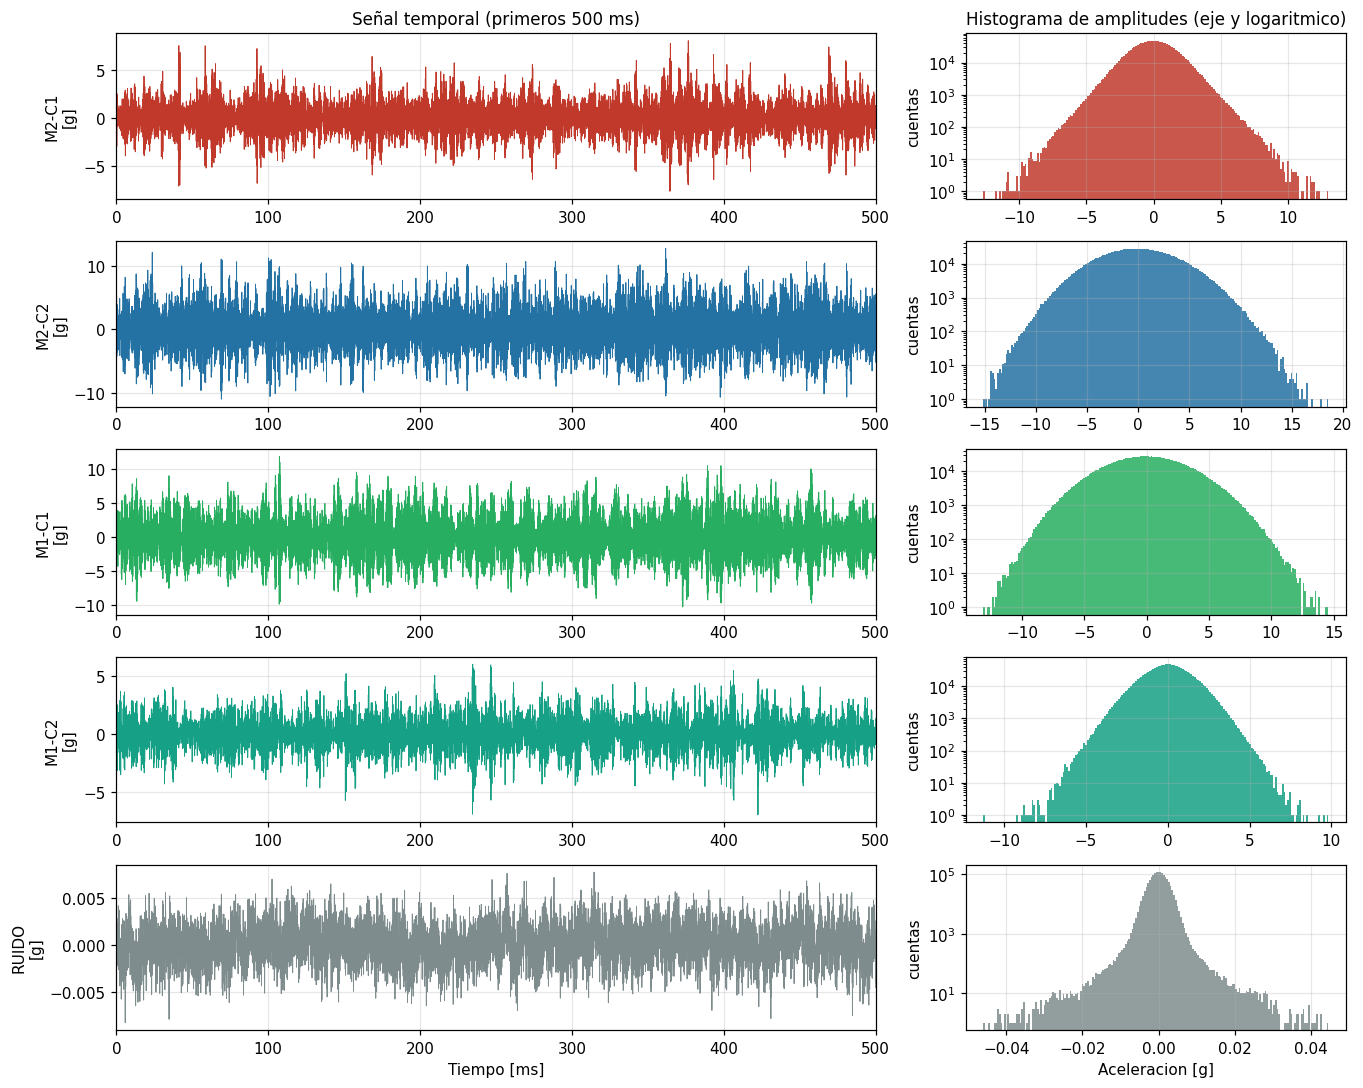

In [101]:
fig, axes = plt.subplots(len(CH), 2, figsize=(12.5, 2.0 * len(CH)),
                         gridspec_kw={"width_ratios": [2, 1]})
for ax_row, (clave, d) in zip(axes, CH.items()):
    x, fs = d["x"], d["fs"]
    c = COLOR[d["rol"]]

    # --- izquierda: 0.5 s de señal temporal ---
    n = int(0.5 * fs)
    ax_row[0].plot(np.arange(n) / fs * 1e3, x[:n], color=c, lw=0.6)
    ax_row[0].set_ylabel(f"{clave}\n[g]")
    ax_row[0].set_xlim(0, 500)
    if clave == list(CH)[0]:
        ax_row[0].set_title("Señal temporal (primeros 500 ms)")

    # --- derecha: histograma en escala log, para ver colas y saturacion ---
    ax_row[1].hist(x, bins=200, color=c, log=True, alpha=0.85)
    ax_row[1].set_ylabel("cuentas")
    if clave == list(CH)[0]:
        ax_row[1].set_title("Histograma de amplitudes (eje y logaritmico)")

axes[-1][0].set_xlabel("Tiempo [ms]")
axes[-1][1].set_xlabel("Aceleracion [g]")
fig.tight_layout()
plt.show()

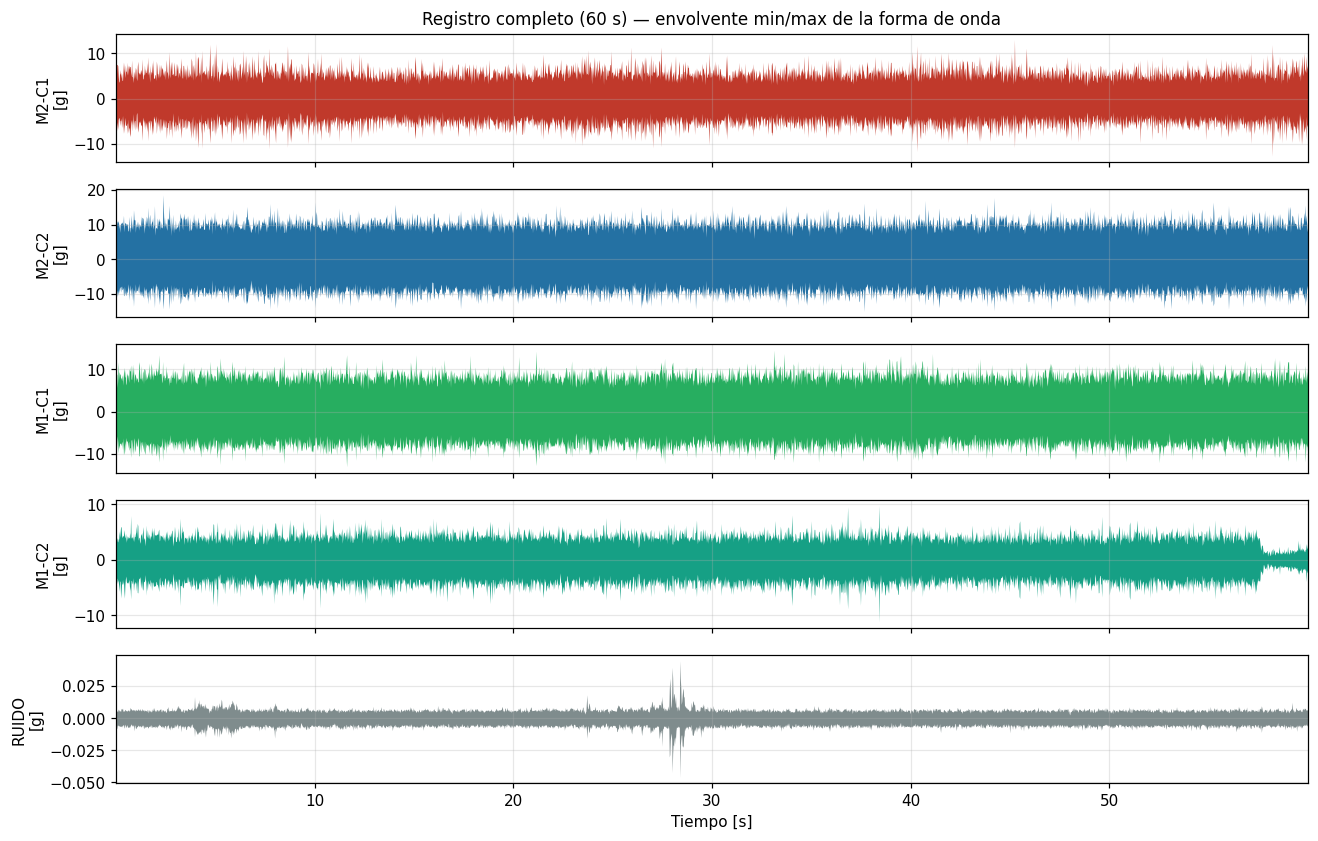

Estacionariedad: RMS por ventana de 1 s (media +- desvio, y su cociente)
  M2-C1 : 1.6832 +- 0.0418 g   (dispersion relativa  2.5 %)
  M2-C2 : 3.4687 +- 0.0619 g   (dispersion relativa  1.8 %)
  M1-C1 : 2.9227 +- 0.0789 g   (dispersion relativa  2.7 %)
  M1-C2 : 1.3641 +- 0.1723 g   (dispersion relativa 12.6 %)
  RUIDO : 0.0023 +- 0.0006 g   (dispersion relativa 28.0 %)


In [102]:
# Vista del registro COMPLETO, con decimacion min/max para no dibujar 1.4 M de puntos.
# Sirve para juzgar estacionariedad: si el nivel cambia a lo largo del registro, promediar
# sobre todo el tramo (Welch, kurtosis global) deja de tener sentido.
fig, axes = plt.subplots(len(CH), 1, figsize=(12, 1.55 * len(CH)), sharex=True)
for a, (clave, d) in zip(axes, CH.items()):
    idx, lo, hi = decimar_minmax(d["x"], 2500)
    t_s = idx / d["fs"]
    a.fill_between(t_s, lo, hi, color=COLOR[d["rol"]], lw=0)
    a.set_ylabel(f"{clave}\n[g]")
    a.margins(x=0)
axes[0].set_title(f"Registro completo ({T_ANALISIS:.0f} s) — envolvente min/max de la "
                  f"forma de onda")
axes[-1].set_xlabel("Tiempo [s]")
fig.tight_layout()
plt.show()

print("Estacionariedad: RMS por ventana de 1 s (media +- desvio, y su cociente)")
for clave, d in CH.items():
    rv = np.sqrt(np.mean(segmentar(d["x"], d["fs"], 1.0) ** 2, axis=1))
    print(f"  {clave:<6}: {rv.mean():.4f} +- {rv.std():.4f} g   "
          f"(dispersion relativa {100*rv.std()/rv.mean():4.1f} %)")

**Lectura.** Los histogramas son campanas sin acumulación en los extremos: **no hay
saturación**. Un registro clipeado mostraría dos barras altas aisladas en $\pm V_{\max}$ y
un corte abrupto de la distribución. La cantidad de muestras exactamente en el valor
extremo es de unidades, como corresponde a un máximo estadístico y no a un recorte.

En la vista del registro completo, M2-C1, M2-C2 y M1-C1 mantienen un nivel **estable**
durante los 60 s: la dispersión del RMS ventana a ventana es del 2–3 %. Eso habilita a
tratarlos como aproximadamente estacionarios y a promediar sobre todo el tramo, que es lo
que hacen Welch y los indicadores globales.

Hay dos excepciones que conviene registrar:

- **RUIDO** tiene un transitorio aislado cerca de los 28 s (dispersión del RMS: 28 %). Es el
  *glitch* que se caracteriza en el paso 2 y que motiva el promediado robusto.
- **M1-C2** cae de nivel en los últimos 2 s del registro (dispersión del RMS: 12.6 %, frente
  al 2–3 % de los demás). Puede ser el final de la adquisición o un cambio de condición de
  la máquina. No afecta el diagnóstico —M1-C2 es sólo un canal de referencia— pero explica
  por qué más adelante aparece con valores atípicos en el RMS por ventana, y es un recordatorio
  de que conviene mirar el registro completo antes de resumirlo en un número.

Obsérvese ya a simple vista que el canal de ruido tiene una amplitud tres órdenes de
magnitud menor que las señales de máquina, y que su histograma tiene colas anormalmente
largas para su desviación estándar: eso es el *glitch* que se caracteriza en el paso 2.

### Estimación empírica de la frecuencia de giro $f_r$

El enunciado indica 1000 rpm, es decir $f_r = 16.667$ Hz. Conviene **medirla** y no
suponerla, porque todo el diagnóstico se expresa como múltiplo de $f_r$: un error del 1 %
en $f_r$ se traduce en un error del 1 % en la identificación de la frecuencia de falla.

La señal de velocidad es ideal para esto: la integración $v = \int a\,dt$ actúa como un
filtro $1/f$ que realza las componentes de baja frecuencia, de modo que el pico $1\times$
(desbalanceo residual, siempre presente en cualquier máquina rotativa) domina el espectro.

In [103]:
FR = {}
for arch, equipo in [("med2_vel_wf.csv", "Vent. 2"), ("med1_vel_wf.csv", "Vent. 1")]:
    _, V, fsv, _ = cargar_wf(arch, FS_LF, t_max=min(T_ANALISIS * 2, 120.0))
    picos = []
    for i in range(V.shape[1]):
        f, P = psd_welch(preparar(V[:, i]), fsv, nperseg=2 ** 15)
        m = (f > 0.6 * FR_NOMINAL) & (f < 1.6 * FR_NOMINAL)   # entorno de 1x
        picos.append(f[m][np.argmax(P[m])])
    FR[arch[:4]] = float(np.mean(picos))
    print(f"{equipo} ({arch}): 1x = {np.mean(picos):.3f} Hz "
          f"-> {np.mean(picos)*60:.1f} rpm   (canales: "
          f"{', '.join(f'{p:.3f}' for p in picos)} Hz)")

fr = FR["med2"]           # frecuencia de giro del equipo bajo estudio
print(f"\nSe adopta fr = {fr:.3f} Hz "
      f"(desvio respecto del nominal {FR_NOMINAL:.3f} Hz: "
      f"{100*(fr-FR_NOMINAL)/FR_NOMINAL:+.2f} %)")

# frecuencias de falla teoricas escaladas a la fr medida
TEO = {k: v * fr for k, v in COEF.items()}
print("\nFrecuencias de falla teoricas a fr medida:")
for k, v in TEO.items():
    print(f"  {k:<6} = {v:8.2f} Hz  ({COEF[k]:6.3f} x fr)")

Vent. 2 (med2_vel_wf.csv): 1x = 16.663 Hz -> 999.8 rpm   (canales: 16.663, 16.663 Hz)
Vent. 1 (med1_vel_wf.csv): 1x = 16.663 Hz -> 999.8 rpm   (canales: 16.663, 16.663 Hz)

Se adopta fr = 16.663 Hz (desvio respecto del nominal 16.667 Hz: -0.02 %)

Frecuencias de falla teoricas a fr medida:
  FTF    =     7.17 Hz  ( 0.430 x fr)
  BSF    =    57.70 Hz  ( 3.463 x fr)
  2xBSF  =   115.40 Hz  ( 6.926 x fr)
  BPFO   =   136.21 Hz  ( 8.175 x fr)
  BPFI   =   180.39 Hz  (10.826 x fr)


---

# 2. Caracterización del ruido del sensor

La medición de ruido (sensor montado, máquina detenida) define el **piso** contra el cual
se mide todo lo demás. Sin ella no se puede afirmar que una componente espectral "existe":
sólo que está por encima de algo.

### PSD por el método de Welch

El periodograma $\hat{P}(f) = |X(f)|^2/(f_s N)$ es un estimador **inconsistente**: su
varianza no disminuye al aumentar $N$. Welch la reduce partiendo la señal en $K$ segmentos
solapados, ventaneando cada uno y promediando:

$$\hat{P}_W(f) \;=\; \frac{1}{K}\sum_{k=1}^{K}
\frac{\left|\sum_{n=0}^{L-1} w[n]\,x_k[n]\,e^{-j2\pi fn/f_s}\right|^2}{f_s\sum_{n} w^2[n]}$$

El precio es resolución: $\Delta f = f_s/L$. Con $L = 2^{14}$ queda $\Delta f = 1.46$ Hz,
suficiente para caracterizar un piso de ruido, que por definición es suave.

### Por qué promediar por mediana

La inspección temporal del registro de ruido muestra un **transitorio aislado** (*glitch*):
un golpe en el cable, un arranque cercano o una descarga electrostática. Ese evento tiene
energía en todas las frecuencias y contamina el o los segmentos donde cae.

La media aritmética es un estimador **no robusto**: un segmento con energía $M$ veces mayor
arrastra el promedio en $M/K$. La mediana, en cambio, tiene punto de ruptura del 50 % —
hace falta contaminar la mitad de los segmentos para moverla. SciPy lo expone como
`welch(..., average='median')`. Se comparan ambas para cuantificar el efecto sobre estos
datos concretos.

RMS global del ruido        : 2.369e-03 g
RMS mediano por ventana     : 2.084e-03 g
RMS de la ventana mas ruidosa: 1.099e-02 g (t = 28.0 s, 5.3x la mediana)
Kurtosis del registro        : 9.76  (0 para ruido gaussiano)


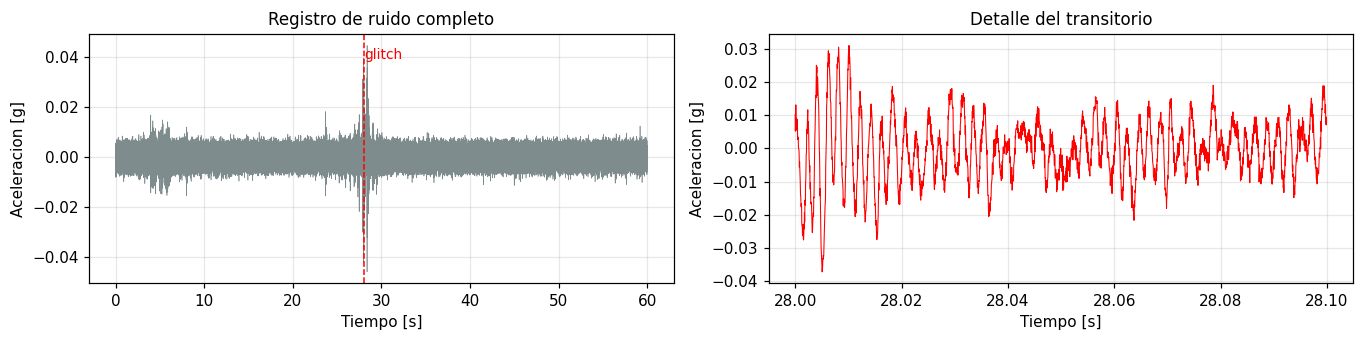

In [104]:
rui = CH["RUIDO"]["x"]
fs = CH["RUIDO"]["fs"]

# --- localizacion del glitch: RMS por ventana corta ---
V = segmentar(rui, fs, t_seg=0.1)
rms_v = np.sqrt(np.mean(V ** 2, axis=1))
t_v = np.arange(len(rms_v)) * 0.1
i_glitch = int(np.argmax(rms_v))

print(f"RMS global del ruido        : {np.sqrt(np.mean(rui**2)):.3e} g")
print(f"RMS mediano por ventana     : {np.median(rms_v):.3e} g")
print(f"RMS de la ventana mas ruidosa: {rms_v[i_glitch]:.3e} g "
      f"(t = {t_v[i_glitch]:.1f} s, {rms_v[i_glitch]/np.median(rms_v):.1f}x la mediana)")
print(f"Kurtosis del registro        : {stats.kurtosis(rui, bias=False):.2f}  "
      f"(0 para ruido gaussiano)")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.2))
ax[0].plot(np.arange(len(rui)) / fs, rui, color=COLOR["ruido"], lw=0.4)
ax[0].axvline(t_v[i_glitch], color="r", ls="--", lw=1)
ax[0].annotate("glitch", xy=(t_v[i_glitch], 0.9), xycoords=("data", "axes fraction"),
               color="r", fontsize=9, ha="left")
ax[0].set(xlabel="Tiempo [s]", ylabel="Aceleracion [g]",
          title="Registro de ruido completo")
n0 = int((t_v[i_glitch]) * fs)
n1 = int((t_v[i_glitch] + 0.1) * fs)
ax[1].plot(np.arange(n0, n1) / fs, rui[n0:n1], color="r", lw=0.7)
ax[1].set(xlabel="Tiempo [s]", ylabel="Aceleracion [g]",
          title="Detalle del transitorio")
fig.tight_layout()
plt.show()

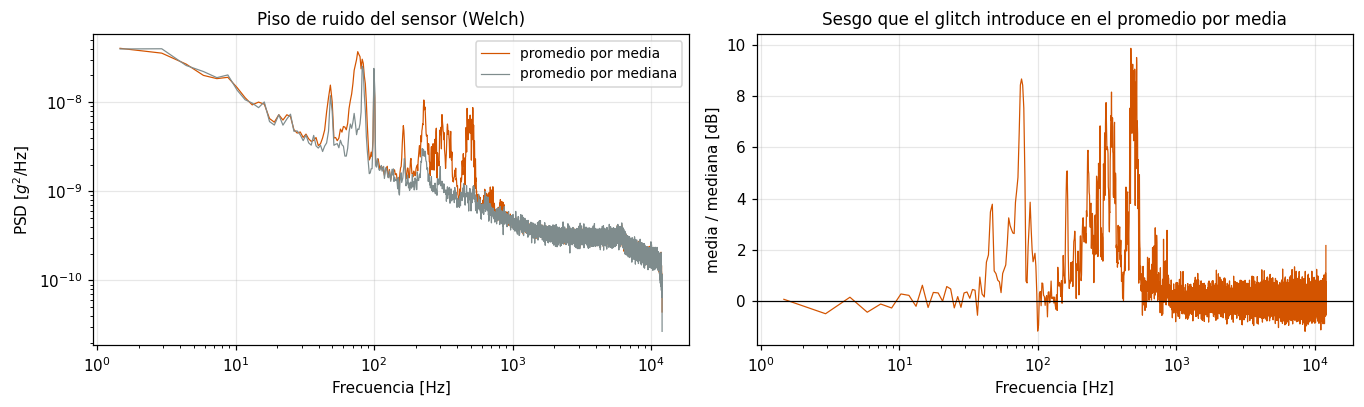

Segmentos promediados: K = 174
Sesgo MEDIANO en frecuencia : +0.03 dB
Sesgo MAXIMO  en frecuencia : +9.87 dB (en 469 Hz)
Fraccion del eje con sesgo > 3 dB: 2.0 %

Piso de ruido (mediana) por banda:
     100 Hz :   -76.7 dB re 1 g^2/Hz
     500 Hz :   -91.4 dB re 1 g^2/Hz
    1000 Hz :   -93.4 dB re 1 g^2/Hz
    2000 Hz :   -94.7 dB re 1 g^2/Hz
    4000 Hz :   -95.6 dB re 1 g^2/Hz
    8000 Hz :   -96.6 dB re 1 g^2/Hz
   11000 Hz :   -98.3 dB re 1 g^2/Hz

Caida de 100 Hz a 11 kHz: -21.6 dB  ->  el ruido NO es blanco


In [105]:
f_n, P_media   = psd_welch(rui, fs, nperseg=NPERSEG_PSD, average="mean")
f_n, P_mediana = psd_welch(rui, fs, nperseg=NPERSEG_PSD, average="median")

# PISO DE RUIDO DE REFERENCIA: se usa en los pasos 4, 5, 9 y 10
PSD_RUIDO = P_mediana
F_RUIDO = f_n

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].loglog(f_n[1:], P_media[1:],   lw=0.8, color="#d35400", label="promedio por media")
ax[0].loglog(f_n[1:], P_mediana[1:], lw=0.8, color=COLOR["ruido"],
             label="promedio por mediana")
ax[0].set(xlabel="Frecuencia [Hz]", ylabel=r"PSD [$g^2$/Hz]",
          title="Piso de ruido del sensor (Welch)")
ax[0].legend()

razon_db = 10 * np.log10(P_media / P_mediana)
ax[1].semilogx(f_n[1:], razon_db[1:], lw=0.8, color="#d35400")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlabel="Frecuencia [Hz]", ylabel="media / mediana [dB]",
          title="Sesgo que el glitch introduce en el promedio por media")
fig.tight_layout()
plt.show()

K = len(rui) // (NPERSEG_PSD // 2) - 1
print(f"Segmentos promediados: K = {K}")
print(f"Sesgo MEDIANO en frecuencia : {np.median(razon_db):+.2f} dB")
print(f"Sesgo MAXIMO  en frecuencia : {np.max(razon_db):+.2f} dB "
      f"(en {f_n[np.argmax(razon_db)]:.0f} Hz)")
print(f"Fraccion del eje con sesgo > 3 dB: {100*np.mean(razon_db > 3):.1f} %")

print("\nPiso de ruido (mediana) por banda:")
for fq in [100, 500, 1000, 2000, 4000, 8000, 11000]:
    print(f"  {fq:>6} Hz : {10*np.log10(np.interp(fq, f_n, P_mediana)):7.1f} dB "
          f"re 1 g^2/Hz")
caida = (10 * np.log10(np.interp(11000, f_n, P_mediana))
         - 10 * np.log10(np.interp(100, f_n, P_mediana)))
print(f"\nCaida de 100 Hz a 11 kHz: {caida:+.1f} dB  ->  el ruido NO es blanco")

**Cuánto importa realmente el promediado robusto, en estos datos.** Con 60 s de registro hay
$K \approx 174$ segmentos y un solo *glitch*, así que el sesgo **mediano** sobre el eje de
frecuencias es de apenas $+0.03$ dB: promediando por media, el piso global casi no se mueve.
Pero el sesgo **no está repartido de manera uniforme**: en las frecuencias donde el
transitorio concentra su energía llega a $+10$ dB. Es decir, la media no desplaza el piso —
le agrega **falsos relieves locales**, que es justamente lo que después se confundiría con
componentes espectrales reales. Con registros más cortos el efecto crece rápidamente (sobre
una ventana de 5 s alrededor del *glitch* el sesgo máximo supera los 15 dB).

Conclusión práctica: el promediado por mediana cuesta lo mismo y no tiene contraindicación;
se lo adopta para el piso de referencia.

### ¿Es ruido blanco?

Un proceso blanco tiene PSD constante y autocorrelación impulsiva:

$$r_{xx}[m] = \sigma^2\,\delta[m]
\quad\Longleftrightarrow\quad
P_{xx}(f) = \sigma^2 \;\; \text{constante}$$

Para decidirlo se usa la autocorrelación normalizada $\rho[m]=r_{xx}[m]/r_{xx}[0]$,
estimada por FFT (teorema de Wiener-Khinchin, $O(N\log N)$ en lugar de $O(N^2)$), y se la
compara con las bandas de confianza del 95 % para la hipótesis de blancura,
$\pm 1.96/\sqrt{N}$.

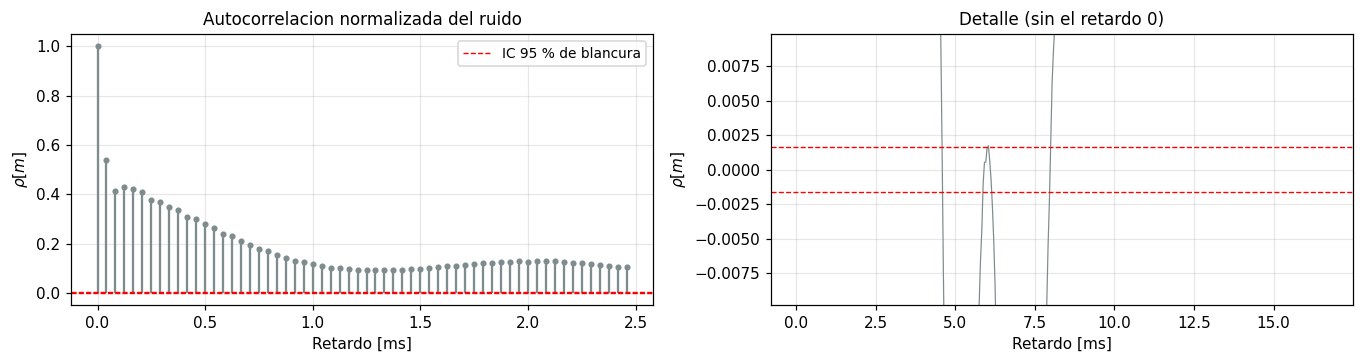

rho[1] = 0.538   rho[5] = 0.411   rho[50] = 0.128   rho[400] = 0.023
IC 95 % de blancura: +-1.63e-03
Retardos fuera del IC 95 %: 98.5 % (seria ~5 % si fuese blanco)
Retardos con |rho| > 0.01 : 379 de 400


In [106]:
def autocorr(x, maxlag):
    # Autocorrelacion insesgada-en-media via FFT (Wiener-Khinchin).
    x = np.asarray(x, float) - np.mean(x)
    N = len(x)
    nfft = 1 << int(np.ceil(np.log2(2 * N)))
    S = np.abs(np.fft.rfft(x, nfft)) ** 2
    r = np.fft.irfft(S, nfft)[:maxlag + 1]
    return r / N


maxlag = 400
r_rui = autocorr(rui, maxlag)
rho = r_rui / r_rui[0]
lim = 1.96 / np.sqrt(len(rui))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
lags_ms = np.arange(maxlag + 1) / fs * 1e3
ax[0].stem(lags_ms[:60], rho[:60], basefmt=" ", markerfmt=".",
           linefmt=COLOR["ruido"])
ax[0].axhline(lim, color="r", ls="--", lw=0.9, label="IC 95 % de blancura")
ax[0].axhline(-lim, color="r", ls="--", lw=0.9)
ax[0].set(xlabel="Retardo [ms]", ylabel=r"$\rho[m]$",
          title="Autocorrelacion normalizada del ruido")
ax[0].legend()

ax[1].plot(lags_ms[1:], rho[1:], lw=0.8, color=COLOR["ruido"])
ax[1].axhline(lim, color="r", ls="--", lw=0.9)
ax[1].axhline(-lim, color="r", ls="--", lw=0.9)
ax[1].set(xlabel="Retardo [ms]", ylabel=r"$\rho[m]$", ylim=(-6 * lim, 6 * lim),
          title="Detalle (sin el retardo 0)")
fig.tight_layout()
plt.show()

print(f"rho[1] = {rho[1]:.3f}   rho[5] = {rho[5]:.3f}   rho[50] = {rho[50]:.3f}   "
      f"rho[400] = {rho[400]:.3f}")
print(f"IC 95 % de blancura: +-{lim:.2e}")
print(f"Retardos fuera del IC 95 %: {100*np.mean(np.abs(rho[1:]) > lim):.1f} % "
      f"(seria ~5 % si fuese blanco)")
print(f"Retardos con |rho| > 0.01 : {np.sum(np.abs(rho[1:]) > 0.01)} de {len(rho)-1}")

**El ruido no es blanco.** La autocorrelación no decae: $\rho[1] = 0.54$ y se mantiene en
torno a $0.35$–$0.40$ hasta retardos de 16 ms, y el 98.5 % de los retardos queda fuera del
intervalo de confianza. Coherentemente, la PSD cae unos **21 dB entre 100 Hz y 11 kHz**: el
ruido está dominado por baja frecuencia. Esto es lo esperable en la cadena de un
acelerómetro piezoeléctrico —ruido $1/f$ del amplificador de carga, deriva térmica,
microfonía del cable— y no un defecto de la medición.

Lo que sí se verifica es que **no hay componentes periódicas**: $\rho[m]$ decae de forma
monótona, sin picos aislados ni oscilaciones sostenidas que delatarían una interferencia
determinística (por ejemplo, acoplamiento de red a 50 Hz).

**Conclusión del paso 2.** El ruido del sensor es coloreado, de banda ancha, sin
periodicidades, y de amplitud muy baja: $\text{RMS} \approx 2.4\times10^{-3}$ g, entre 40 y
60 dB por debajo de las señales de máquina según la banda (se cuantifica en el paso 4). No
limita el análisis, pero sí define contra qué se mide.

`PSD_RUIDO` queda guardado como piso de referencia. Se lo usa para (a) verificar que los
picos espectrales del paso 4 son reales, (b) descartar bandas sin energía en el kurtograma
del paso 5, y (c) validar el rango dinámico en los indicadores de salud del paso 9.

---

# 3. Indicadores en el dominio temporal

Cuatro escalares clásicos, todos sobre la señal ya preparada (sin continua ni deriva):

$$
\text{RMS} = \sqrt{\frac{1}{N}\sum_n x^2[n]}
\qquad
C_f = \frac{\max_n |x[n]|}{\text{RMS}}
$$

$$
\text{Kurt} = \frac{\frac{1}{N}\sum_n (x[n]-\bar x)^4}{\left[\frac{1}{N}\sum_n (x[n]-\bar x)^2\right]^2} - 3
\qquad
\text{Skew} = \frac{\frac{1}{N}\sum_n (x[n]-\bar x)^3}{\left[\frac{1}{N}\sum_n (x[n]-\bar x)^2\right]^{3/2}}
$$

Qué mide cada uno y por qué importa la distinción:

- **RMS**: energía total de la vibración. Es el indicador normado (ISO 10816) y detecta bien
  desbalanceo, desalineación o soltura, que son fallas *distribuidas* y de gran amplitud.
- **Factor de cresta $C_f$**: cuán picuda es la señal. Para una sinusoide vale $\sqrt2$;
  para ruido gaussiano, $\approx 3$–$4$ según $N$.
- **Kurtosis** (aquí en su forma *exceso*, con el $-3$): cuarto momento normalizado. Vale
  $0$ para una distribución gaussiana y crece cuando hay **eventos raros de gran
  amplitud** — exactamente la firma de una falla localizada, que produce un impacto por
  cada paso del defecto y silencio entre medio.
- **Skewness**: asimetría. Se espera $\approx 0$; una desviación fuerte sugiere rozamiento
  unidireccional o problemas de montaje.

La distinción entre RMS y kurtosis es el punto central de este paso: **una falla localizada
incipiente cambia la *forma* de la señal mucho antes que su *energía***. Los datos de este
TP lo muestran de manera particularmente clara.

In [107]:
filas = []
for clave, d in CH.items():
    ind = indicadores_tiempo(d["x"])
    ind = {"canal": clave, "descripcion": d["desc"], **ind}
    filas.append(ind)

tabla_t = pd.DataFrame(filas).set_index("canal")
display(tabla_t.style.format({"RMS": "{:.4f}", "Pico": "{:.3f}", "Cresta": "{:.2f}",
                              "Kurtosis": "{:.3f}", "Skewness": "{:+.3f}"}))

r1, r2 = tabla_t.loc["M2-C1"], tabla_t.loc["M2-C2"]
print(f"Comparacion dentro del MISMO equipo (Vent. 2):")
print(f"  RMS      : C1 = {r1['RMS']:.3f} g   vs   C2 = {r2['RMS']:.3f} g"
      f"   -> C2 es {r2['RMS']/r1['RMS']:.2f}x MAYOR")
print(f"  Kurtosis : C1 = {r1['Kurtosis']:.3f}    vs   C2 = {r2['Kurtosis']:.3f}"
      f"   -> C1 es el impulsivo")

,descripcion,RMS,Pico,Cresta,Kurtosis,Skewness
canal,,,,,,
M2-C1,"Vent. 2, lado acople (sospecha de falla)",1.6837,13.024,7.74,1.098,+0.055
M2-C2,"Vent. 2, lado libre (mismo equipo)",3.4692,18.587,5.36,-0.006,+0.074
M1-C1,"Vent. 1, punto A (equipo de referencia)",2.9238,14.576,4.99,-0.015,+0.046
M1-C2,"Vent. 1, punto B (equipo de referencia)",1.3750,11.274,8.20,0.577,-0.017
RUIDO,Sensor sin maquina (piso de ruido),0.0024,0.046,19.43,9.757,-0.029


Comparacion dentro del MISMO equipo (Vent. 2):
  RMS      : C1 = 1.684 g   vs   C2 = 3.469 g   -> C2 es 2.06x MAYOR
  Kurtosis : C1 = 1.098    vs   C2 = -0.006   -> C1 es el impulsivo


> **Resultado clave.** El canal C2 del ventilador 2 tiene **más del doble de RMS** que el
> canal C1, pero una kurtosis prácticamente nula. Si el criterio de alarma fuese el nivel
> global de vibración —que es el criterio normado y el más difundido— se señalaría el canal
> **equivocado**.
>
> La explicación física: el lado libre soporta el ventilador y ve mayor vibración
> sincrónica (desbalanceo del rotor, paso de álabes), que es de gran amplitud pero
> perfectamente **gaussiana y estacionaria**, y por lo tanto de kurtosis nula. El lado
> acople tiene menos energía total, pero contiene un tren de impactos que la kurtosis sí
> detecta. Ésta es la razón de ser de todo el resto del notebook.

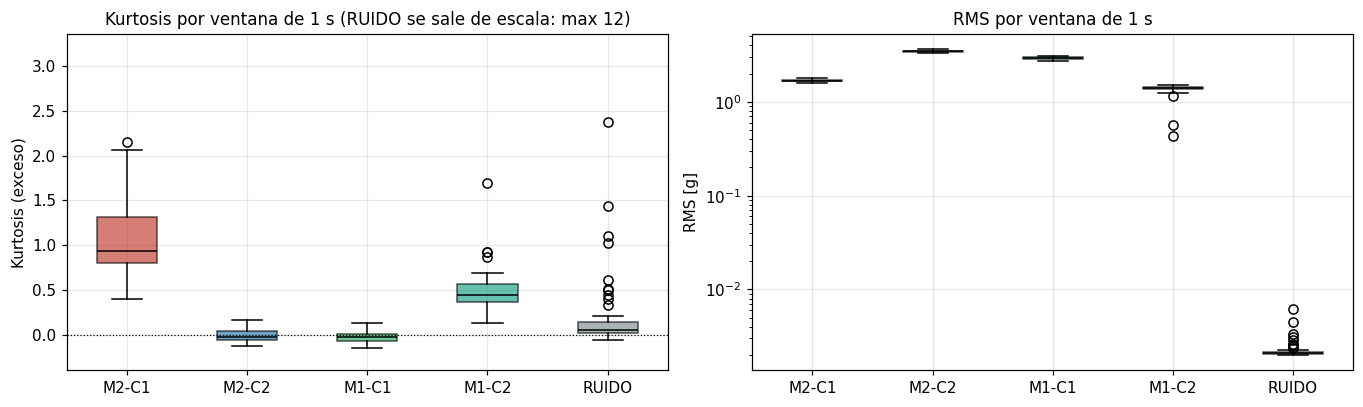

Kurtosis por ventana: media +- desvio
  M2-C1 : +1.067 +- 0.396   (min +0.40, max +2.15)
  M2-C2 : -0.009 +- 0.064   (min -0.13, max +0.16)
  M1-C1 : -0.023 +- 0.067   (min -0.15, max +0.12)
  M1-C2 : +0.481 +- 0.225   (min +0.13, max +1.70)
  RUIDO : +0.483 +- 1.752   (min -0.06, max +12.22)


In [108]:
# Los indicadores como variables aleatorias: una realizacion por ventana de 1 s.
kurt_v, rms_v_ch, claves = {}, {}, list(CH)
for clave, d in CH.items():
    V = segmentar(d["x"], d["fs"], t_seg=T_VENTANA)
    kurt_v[clave] = stats.kurtosis(V, axis=1, bias=False)
    rms_v_ch[clave] = np.sqrt(np.mean(V ** 2, axis=1))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
colores = [COLOR[CH[k]["rol"]] for k in claves]

bp = ax[0].boxplot([kurt_v[k] for k in claves], tick_labels=claves, patch_artist=True,
                   medianprops={"color": "k"})
for caja, c in zip(bp["boxes"], colores):
    caja.set_facecolor(c)
    caja.set_alpha(0.65)
ax[0].axhline(0, color="k", lw=0.8, ls=":")
# el glitch del ruido llega a kurtosis ~12 y aplastaria el resto: se recorta el eje
_kmax = max(np.percentile(kurt_v[k], 99) for k in claves if k != "RUIDO")
ax[0].set(ylabel="Kurtosis (exceso)", ylim=(-0.4, _kmax * 1.6),
          title=f"Kurtosis por ventana de {T_VENTANA:.0f} s "
                f"(RUIDO se sale de escala: max {kurt_v['RUIDO'].max():.0f})")

bp = ax[1].boxplot([rms_v_ch[k] for k in claves], tick_labels=claves, patch_artist=True,
                   medianprops={"color": "k"})
for caja, c in zip(bp["boxes"], colores):
    caja.set_facecolor(c)
    caja.set_alpha(0.65)
ax[1].set(ylabel="RMS [g]", yscale="log", title=f"RMS por ventana de {T_VENTANA:.0f} s")
fig.tight_layout()
plt.show()

print("Kurtosis por ventana: media +- desvio")
for k in claves:
    print(f"  {k:<6}: {kurt_v[k].mean():+.3f} +- {kurt_v[k].std():.3f}   "
          f"(min {kurt_v[k].min():+.2f}, max {kurt_v[k].max():+.2f})")

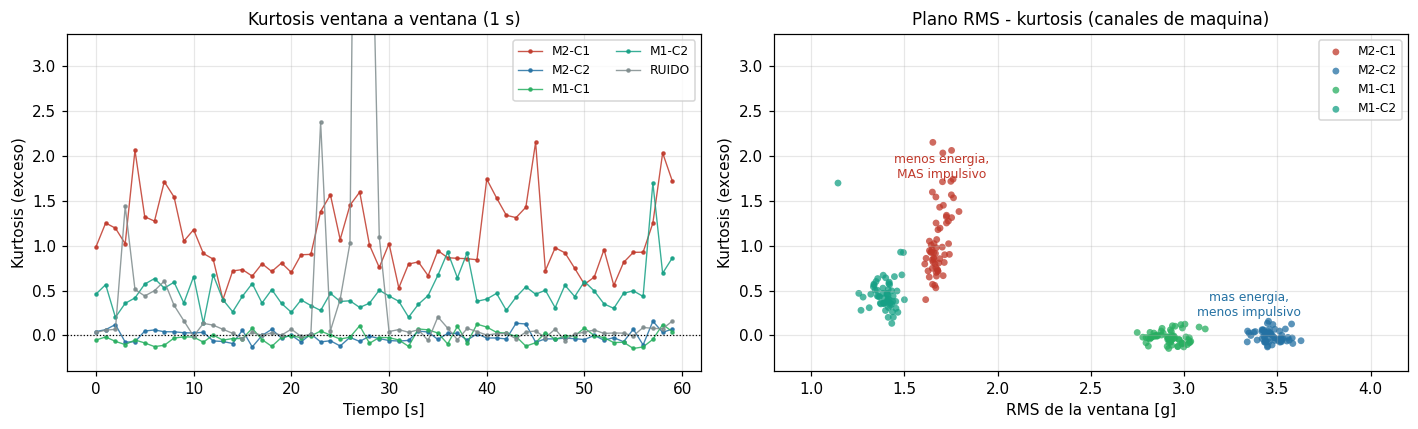

In [109]:
maq = [k for k in claves if k != "RUIDO"]     # solo canales de maquina
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# --- evolucion temporal de la kurtosis ---
for clave in claves:
    ax[0].plot(np.arange(len(kurt_v[clave])) * T_VENTANA, kurt_v[clave], ".-", ms=4,
               lw=0.9, color=COLOR[CH[clave]["rol"]], alpha=0.85, label=clave)
ax[0].axhline(0, color="k", lw=0.8, ls=":")
ax[0].set(xlabel="Tiempo [s]", ylabel="Kurtosis (exceso)", ylim=(-0.4, _kmax * 1.6),
          title=f"Kurtosis ventana a ventana ({T_VENTANA:.0f} s)")
ax[0].legend(fontsize=8, ncol=2)

# --- el plano RMS - kurtosis, solo canales de maquina ---
for clave in maq:
    ax[1].scatter(rms_v_ch[clave], kurt_v[clave], s=20, alpha=0.75, edgecolors="none",
                  color=COLOR[CH[clave]["rol"]], label=clave)
ax[1].annotate("mas energia,\nmenos impulsivo", xy=(3.35, 0.22), fontsize=8,
               color="#2471a3", ha="center")
ax[1].annotate("menos energia,\nMAS impulsivo", xy=(1.70, 1.75), fontsize=8,
               color=COLOR["falla"], ha="center")
ax[1].set(xlabel="RMS de la ventana [g]", ylabel="Kurtosis (exceso)",
          xlim=(0.8, 4.2), ylim=(-0.4, _kmax * 1.6),
          title="Plano RMS - kurtosis (canales de maquina)")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

La kurtosis elevada de M2-C1 es **persistente**: la caja completa está por encima de las de
los demás canales, y la traza temporal muestra que se mantiene en todas las ventanas del
registro — no es una ventana atípica. El ruido, en cambio, muestra kurtosis alta con enorme
dispersión: es el *glitch* del paso 2 concentrado en unas pocas ventanas, y se lo ve como
picos aislados sobre una línea de base nula. Esa diferencia —desplazamiento sistemático de
toda la distribución frente a unos pocos valores extremos— es lo que distingue una falla de
un artefacto de medición, y es el argumento para usar estadísticos por ventana en lugar de
un escalar global.

El plano RMS–kurtosis resume el punto del paso: los grupos se separan **verticalmente**
(kurtosis) y no horizontalmente (RMS). M2-C1 está arriba a la izquierda —poca energía, mucha
impulsividad— y M2-C2 abajo a la derecha. Proyectar sobre el eje horizontal, que es lo que
hace un criterio de nivel global, mezcla las dos poblaciones.

---

# 4. Espectro clásico: Welch y modelo AR

### Qué se espera ver (y qué no)

En el espectro de aceleración de una máquina rotativa conviven:

- las **componentes sincrónicas**: $1\times f_r$ (desbalanceo), $2\times f_r$
  (desalineación), y el paso de álabes $N_{\text{álabes}}\times f_r$ — todas múltiplos
  **enteros** de $f_r$;
- las **componentes de falla de rodamiento**, en múltiplos **no enteros** de $f_r$ y de
  amplitud mucho menor;
- las **resonancias estructurales** excitadas por los impactos, como elevaciones anchas
  (*humps*) en alta frecuencia.

El punto importante: **la falla de rodamiento casi nunca se ve directamente acá**. La
energía de cada impacto se reparte sobre toda la banda de resonancia, de modo que la línea
espectral a BPFI queda enterrada. Lo que sí se ve es el *hump*. Este paso sirve entonces
para dos cosas: descartar que el problema sea sincrónico, y localizar visualmente la banda
de resonancia que el paso 5 va a seleccionar de forma automática y cuantitativa.

### Primero: por qué Welch y no el periodograma

El periodograma simple,
$$\hat{P}_{per}(f) = \frac{1}{f_s N}\left|\sum_{n=0}^{N-1} x[n]e^{-j2\pi fn/f_s}\right|^2,$$
es un estimador **asintóticamente insesgado pero inconsistente**: su varianza tiende a
$P^2(f)$ y **no disminuye** al crecer $N$. Aumentar el registro agrega resolución, no
precisión — la curva sigue igual de erizada. Welch cambia resolución por varianza:
promediando $K$ segmentos independientes la varianza cae como $1/K$.

La primera figura lo muestra sobre la señal real. La segunda ilustra el otro compromiso, el
de las **ventanas**: como $x_w[n] = x[n]w[n]$ implica $X_w(f) = X(f) * W(f)$, el espectro
que se observa es el verdadero **convolucionado con la transformada de la ventana**. La
rectangular tiene el lóbulo principal más angosto —mejor resolución— pero lóbulos laterales
altos, que derraman energía de los picos fuertes sobre todo el eje (*leakage*). Hann y
Blackman ensanchan el lóbulo principal a cambio de hundir los laterales.

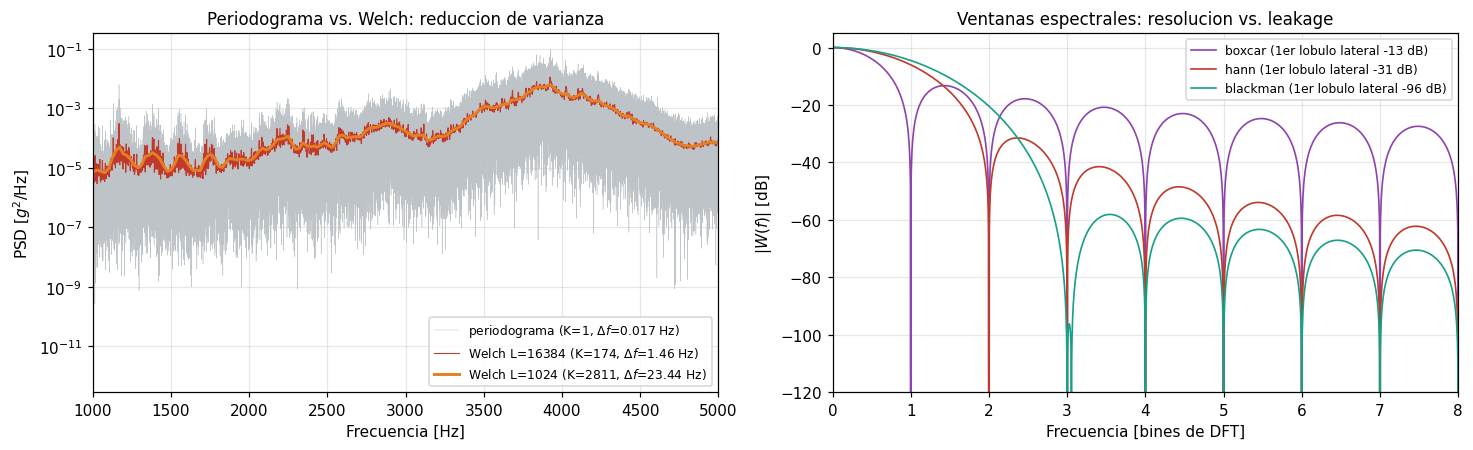

Erizado del estimador en 2-3 kHz (desvio de P / suavizado de P):
  periodograma   : 1.499   (K=1)
  Welch L=1024  : 0.207   (K=2811, reduccion 7.3x, cota ideal 1/sqrt(K) = 0.019)
  Welch L=16384 : 0.420   (K=174, reduccion 3.6x, cota ideal 1/sqrt(K) = 0.076)

Efecto de la ventana sobre ESTA señal (PSD media entre 1x y 2x de fr):
  boxcar   : 5.9137e-06
  hann     : 5.9069e-06
  blackman : 6.0767e-06


In [110]:
x1 = CH["M2-C1"]["x"]

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))

# --- periodograma vs Welch ---
f_per, P_per = signal.periodogram(x1, FS_ACEL, window="boxcar")
ax[0].semilogy(f_per[1:], P_per[1:], lw=0.3, color="#bdc3c7",
               label=f"periodograma (K=1, $\\Delta f$={FS_ACEL/len(x1):.3f} Hz)")
for L, c, lw in [(2 ** 14, COLOR["falla"], 0.7), (2 ** 10, "#e67e22", 1.9)]:
    fw, Pw = psd_welch(x1, FS_ACEL, nperseg=L)
    K = len(x1) // (L // 2) - 1
    ax[0].semilogy(fw[1:], Pw[1:], lw=lw, color=c,
                   label=f"Welch L={L} (K={K}, $\\Delta f$={FS_ACEL/L:.2f} Hz)")
ax[0].set(xlabel="Frecuencia [Hz]", ylabel=r"PSD [$g^2$/Hz]", xlim=(1000, 5000),
          title="Periodograma vs. Welch: reduccion de varianza")
ax[0].legend(fontsize=8, loc="lower right")

# --- las ventanas mismas: lobulo principal vs lobulos laterales ---
L_w = 256
for vent, c in [("boxcar", "#8e44ad"), ("hann", COLOR["falla"]), ("blackman", "#16a085")]:
    w = signal.get_window(vent, L_w)
    W = np.abs(np.fft.rfft(w, 1 << 16))
    Wd = 20 * np.log10(W / W.max() + 1e-16)
    bins = np.arange(len(Wd)) * L_w / (1 << 16)      # en "bines de DFT"
    pk, _ = signal.find_peaks(Wd)
    ax[1].plot(bins, Wd, lw=1.1, color=c,
               label=f"{vent} (1er lobulo lateral {Wd[pk[0]]:.0f} dB)")
ax[1].set(xlabel="Frecuencia [bines de DFT]", ylabel=r"$|W(f)|$ [dB]",
          xlim=(0, 8), ylim=(-120, 5),
          title="Ventanas espectrales: resolucion vs. leakage")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- cuantificacion de la varianza del estimador ---
# No alcanza con el desvio de P sobre una banda: eso mide la FORMA del espectro, no el
# ruido del estimador. Se divide P por una version suavizada de si misma (filtro de
# mediana) y se mide la dispersion del cociente, que aisla el "erizado".
from scipy import ndimage


def jitter(f, P, lo=2000, hi=3000, n_med=41):
    suave = ndimage.median_filter(P, size=n_med, mode="nearest")
    m = (f > lo) & (f < hi)
    return float((P[m] / suave[m]).std())


j_per = jitter(f_per, P_per)
print(f"Erizado del estimador en 2-3 kHz (desvio de P / suavizado de P):")
print(f"  periodograma   : {j_per:.3f}   (K=1)")
for L in [2 ** 10, 2 ** 14]:
    fw, Pw = psd_welch(x1, FS_ACEL, nperseg=L)
    K = len(x1) // (L // 2) - 1
    j = jitter(fw, Pw, n_med=11 if L < 4096 else 41)
    print(f"  Welch L={L:<6}: {j:.3f}   (K={K}, reduccion {j_per/j:.1f}x, "
          f"cota ideal 1/sqrt(K) = {1/np.sqrt(K):.3f})")

print("\nEfecto de la ventana sobre ESTA señal (PSD media entre 1x y 2x de fr):")
for vent in ["boxcar", "hann", "blackman"]:
    fw, Pw = psd_welch(x1, FS_ACEL, nperseg=2 ** 16, ventana=vent)
    mw = (fw > 20) & (fw < 30)
    print(f"  {vent:<9}: {Pw[mw].mean():.4e}")

El periodograma (gris) es una nube que cubre varios órdenes de magnitud alrededor del valor
verdadero, y lo sigue siendo aunque se use el registro completo de 1.44 millones de
muestras: su varianza no depende de $N$. Welch promedia segmentos y reduce el erizado en un
factor de entre 4 y 7 según $L$. Sobre esa curva suave sí se puede decidir si una elevación
es una resonancia o ruido de estimación — y ahí aparece con claridad el *hump* centrado
cerca de 3.9 kHz.

La reducción medida **no llega** a la cota ideal $1/\sqrt{K}$, y conviene entender por qué:
los segmentos de Welch se solapan al 50 %, de modo que no son independientes y el $K$
efectivo es cerca de la mitad; y parte de lo que el indicador cuenta como "erizado" es
estructura espectral real de la señal (armónicos, bandas laterales) que el suavizado por
mediana no elimina. La cota vale para ruido blanco con segmentos disjuntos, no para esta
señal.

La figura de la derecha muestra por qué existe el compromiso de ventaneo: la rectangular
tiene el lóbulo principal más angosto, pero sus lóbulos laterales caen sólo a −13 dB; Hann
llega a −31 dB y Blackman a −97 dB, a costa de un lóbulo principal dos y tres veces más
ancho.

> **Pero conviene ser honesto con lo que pasa en estos datos.** Medido sobre la señal real,
> las tres ventanas dan PSDs que difieren menos del 3 % — el número está impreso arriba. El
> *leakage* no es un problema acá porque la señal es de **banda ancha**: no hay una
> componente estrecha tan dominante como para que sus lóbulos laterales tapen a las vecinas.
> El ventaneo es crítico cuando se quiere resolver una componente débil al lado de una muy
> fuerte, que no es esta situación. Se usa Hann en todo el notebook por ser la elección
> conservadora estándar, no porque acá cambie el resultado.

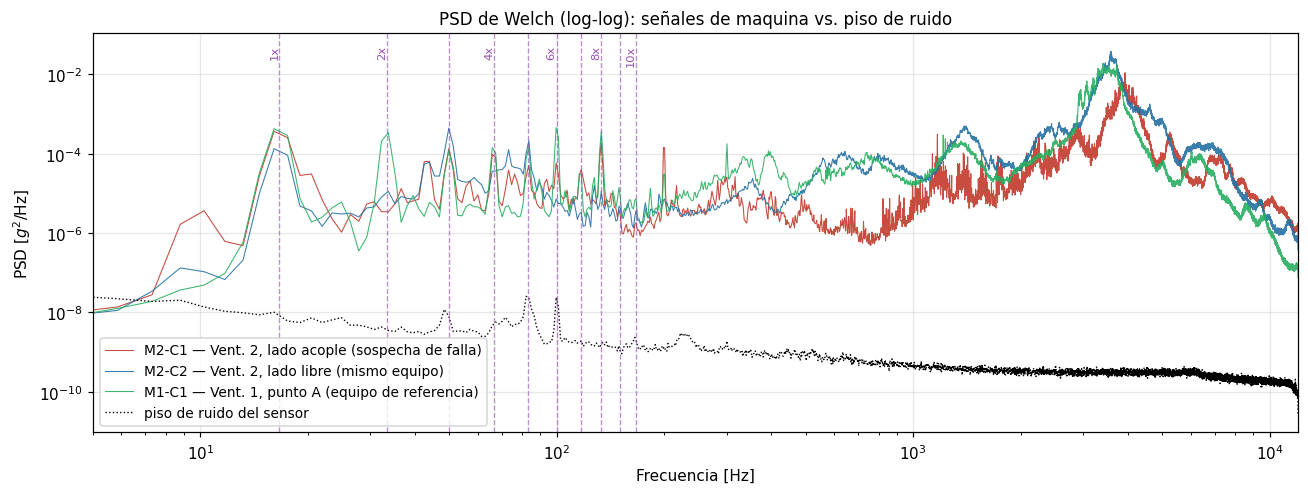

Margen señal/ruido por banda (M2-C1):
     10-100   Hz :  36.8 dB
    100-500   Hz :  38.0 dB
    500-2000  Hz :  44.5 dB
   2000-5000  Hz :  64.4 dB
   5000-9000  Hz :  53.0 dB
   9000-11800 Hz :  44.2 dB


In [111]:
fig, ax = plt.subplots(figsize=(12, 4.6))
for clave in ["M2-C1", "M2-C2", "M1-C1"]:
    d = CH[clave]
    f, P = psd_welch(d["x"], d["fs"], nperseg=NPERSEG_PSD)
    ax.loglog(f[1:], P[1:], lw=0.7, color=COLOR[d["rol"]] if clave != "M1-C1" else COLOR["ref"],
              alpha=0.9, label=f"{clave} — {d['desc']}")
ax.loglog(F_RUIDO[1:], PSD_RUIDO[1:], lw=0.9, color="k", ls=":",
          label="piso de ruido del sensor")

marcar(ax, [k * fr for k in range(1, 11)],
       [f"{k}x" if k in (1, 2, 4, 6, 8, 10) else None for k in range(1, 11)],
       color="#8e44ad")
ax.set(xlabel="Frecuencia [Hz]", ylabel=r"PSD [$g^2$/Hz]",
       title="PSD de Welch (log-log): señales de maquina vs. piso de ruido",
       xlim=(5, FS_ACEL / 2))
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

# margen sobre el ruido, por banda
print("Margen señal/ruido por banda (M2-C1):")
f, P1 = psd_welch(CH["M2-C1"]["x"], FS_ACEL, nperseg=NPERSEG_PSD)
Pr = np.interp(f, F_RUIDO, PSD_RUIDO)
for lo, hi in [(10, 100), (100, 500), (500, 2000), (2000, 5000), (5000, 9000), (9000, 11800)]:
    m = (f >= lo) & (f < hi)
    print(f"  {lo:>5}-{hi:<5} Hz : {10*np.log10(P1[m].mean()/Pr[m].mean()):5.1f} dB")

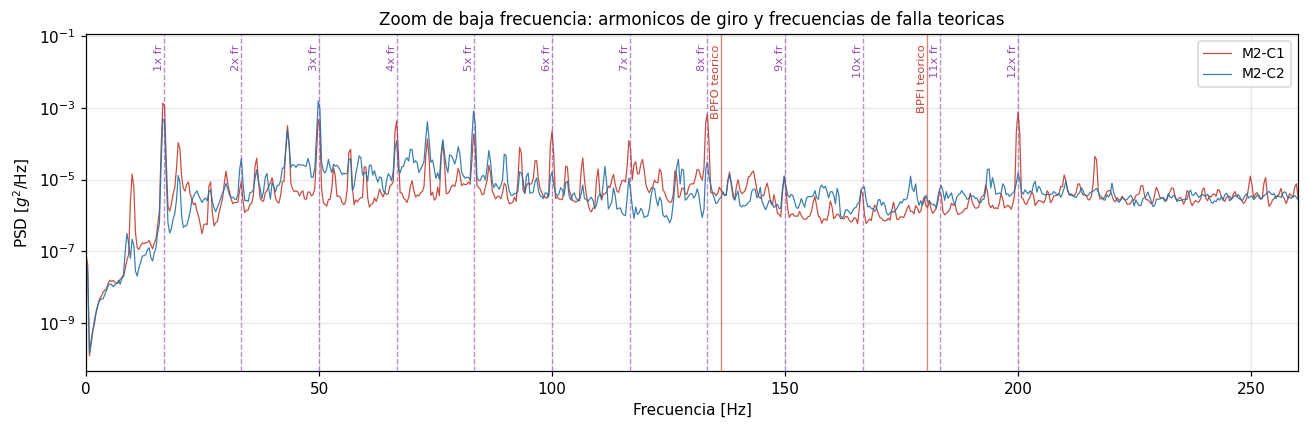

In [112]:
# Zoom en la region de baja frecuencia: componentes sincronicas
fig, ax = plt.subplots(figsize=(12, 4))
for clave in ["M2-C1", "M2-C2"]:
    d = CH[clave]
    f, P = psd_welch(d["x"], d["fs"], nperseg=2 ** 16)
    ax.semilogy(f, P, lw=0.8, color=COLOR[d["rol"]], alpha=0.9, label=clave)
marcar(ax, [k * fr for k in range(1, 13)],
       [f"{k}x fr" for k in range(1, 13)], color="#8e44ad")
marcar(ax, [TEO["BPFI"], TEO["BPFO"]], ["BPFI teorico", "BPFO teorico"],
       color=COLOR["falla"], ls="-")
ax.set(xlabel="Frecuencia [Hz]", ylabel=r"PSD [$g^2$/Hz]", xlim=(0, 260),
       title="Zoom de baja frecuencia: armonicos de giro y frecuencias de falla teoricas")
ax.legend()
fig.tight_layout()
plt.show()

Como se anticipaba, en la zona de baja frecuencia dominan los múltiplos enteros de $f_r$ y
**no hay nada reconocible** en BPFI ni en BPFO. Confirmado: el espectro de aceleración
convencional no resuelve este diagnóstico. En cambio, en el gráfico log-log anterior se
distingue un ensanchamiento del espectro de M2-C1 en la zona de los kHz respecto del canal
sano — ése es el *hump* de resonancia.

### Estimación paramétrica: modelo AR y Yule-Walker

Un modelo autorregresivo de orden $p$ describe la señal como ruido blanco filtrado por un
sistema todo-polos:

$$x[n] = -\sum_{k=1}^{p} a_k\,x[n-k] + w[n],
\qquad
\hat{P}_{AR}(f) = \frac{\sigma_w^2/f_s}{\left|1 + \sum_{k=1}^{p} a_k e^{-j2\pi f k/f_s}\right|^2}$$

Los coeficientes salen de las **ecuaciones de Yule-Walker**, que relacionan $a_k$ con la
autocorrelación del proceso:

$$
\begin{bmatrix}
r[0] & r[1] & \cdots & r[p-1]\\
r[1] & r[0] & \cdots & r[p-2]\\
\vdots & & \ddots & \vdots\\
r[p-1] & r[p-2] & \cdots & r[0]
\end{bmatrix}
\begin{bmatrix} a_1\\ a_2\\ \vdots\\ a_p\end{bmatrix}
=
\begin{bmatrix} r[1]\\ r[2]\\ \vdots\\ r[p]\end{bmatrix}
$$

La matriz es **Toeplitz**, lo que permite resolver en $O(p^2)$ con Levinson-Durbin
(`scipy.linalg.solve_toeplitz`) en lugar de $O(p^3)$.

**Ventaja frente a Welch**: el AR no ventanea, así que no sufre *leakage* ni está limitado
por $\Delta f = f_s/L$. Con registros cortos puede resolver componentes que Welch fusiona.
**Desventaja**: impone un modelo todo-polos. Si la señal no es AR, ajusta picos donde no
los hay o los desplaza.

Para que la comparación sea informativa se trabaja sobre la señal **diezmada a 1500 Hz**
(con el filtro antialias de `scipy.signal.decimate`) y con un **registro corto de 2 s**:
ése es el régimen donde los métodos paramétricos muestran su ventaja. Con 60 s de señal a
24 kHz, Welch tiene tantos segmentos para promediar que no hay nada que discutir.

Señal diezmada: fs = 1500 Hz, registro de 2.0 s -> N = 3000 muestras


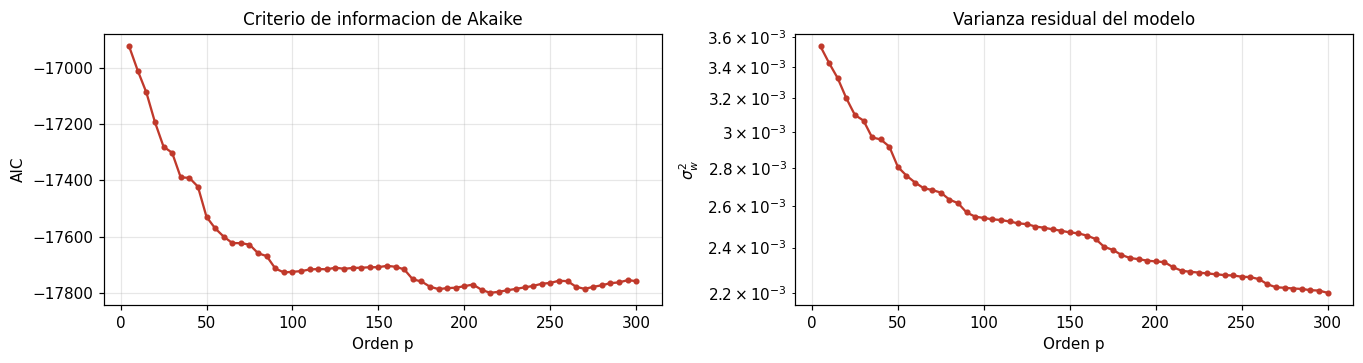

AIC minimo en p = 215   FPE minimo en p = 215
Ordenes con delta-AIC <= 2 (indistinguibles del optimo): [np.int64(215)]
El optimo usa 215 parametros para 3000 muestras: 1 cada 14 -> modelo poco creible fisicamente
Criterio de la rodilla (mejora relativa < 0.5 % cada +5 ordenes): p = 40


In [113]:
def ar_yule_walker(r, p):
    # Resuelve Yule-Walker a partir de la autocorrelacion r. Devuelve (a, sigma2)
    # con la convencion x[n] = sum a_k x[n-k] + w[n].
    a = linalg.solve_toeplitz((r[:p], r[:p]), r[1:p + 1])
    return a, float(r[0] - a @ r[1:p + 1])


def psd_ar(a, sigma2, fs, nfft=4096):
    w, h = signal.freqz(np.sqrt(sigma2), np.r_[1.0, -a], worN=nfft, fs=fs)
    return w, np.abs(h) ** 2 / fs


Q = 16                                   # factor de diezmado
T_CORTO = 2.0                            # s de registro para la comparacion
xd = signal.decimate(CH["M2-C1"]["x"], Q, ftype="fir", zero_phase=True)
fsd = FS_ACEL / Q
xs = xd[:int(fsd * T_CORTO)]
N = len(xs)
print(f"Señal diezmada: fs = {fsd:.0f} Hz, registro de {T_CORTO} s -> N = {N} muestras")

# --- seleccion de orden ---
p_max = 300
r_xs = autocorr(xs, p_max)
ordenes = np.arange(5, p_max + 1, 5)
sig2 = np.array([ar_yule_walker(r_xs, int(p))[1] for p in ordenes])
aic = N * np.log(sig2) + 2 * ordenes
fpe = sig2 * (N + ordenes) / (N - ordenes)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
ax[0].plot(ordenes, aic, ".-", color=COLOR["falla"])
ax[0].set(xlabel="Orden p", ylabel="AIC", title="Criterio de informacion de Akaike")
ax[1].semilogy(ordenes, sig2, ".-", color=COLOR["falla"])
ax[1].set(xlabel="Orden p", ylabel=r"$\sigma_w^2$",
          title="Varianza residual del modelo")
fig.tight_layout()
plt.show()

p_aic = int(ordenes[np.argmin(aic)])
print(f"AIC minimo en p = {p_aic}   FPE minimo en p = {ordenes[np.argmin(fpe)]}")

# convencion habitual: modelos con delta-AIC <= 2 son indistinguibles entre si
meseta = ordenes[aic <= aic.min() + 2]
print(f"Ordenes con delta-AIC <= 2 (indistinguibles del optimo): {list(meseta)}")
print(f"El optimo usa {p_aic} parametros para {N} muestras: "
      f"1 cada {N/p_aic:.0f} -> modelo poco creible fisicamente")

# --- criterio de la rodilla: primer orden con mejora relativa < 0.5 % ---
mejora = -np.diff(np.log(sig2)) / np.diff(ordenes) * 5     # por cada +5 de orden
p_opt = int(ordenes[1:][np.argmax(mejora < 0.005)])
print(f"Criterio de la rodilla (mejora relativa < 0.5 % cada +5 ordenes): p = {p_opt}")

**Sobre la selección de orden.** El AIC penaliza la complejidad con $2p$, un término que
crece linealmente mientras $N\log\sigma_w^2$ decrece. Sobre esta señal el AIC tiene un
mínimo interior, pero lo ubica en un orden **muy alto**: $p \approx 215$ para $N = 3000$
muestras, o sea **un parámetro cada 14 muestras**. Como modelo físico de la vibración de un
ventilador eso no es creíble; es el síntoma clásico de un modelo mal especificado —la señal
no es un proceso AR de orden finito— donde el AIC sigue "comprando" reducción de residuo
ajustando ruido.

Se lo contrasta con el criterio de la **rodilla** de la curva $\sigma_w^2(p)$ —el orden a
partir del cual agregar polos ya no mejora apreciablemente el ajuste—, que da $p \approx 40$,
mucho más parsimonioso. Los dos criterios difieren en un factor cinco: la figura siguiente
decide cuál sirve.

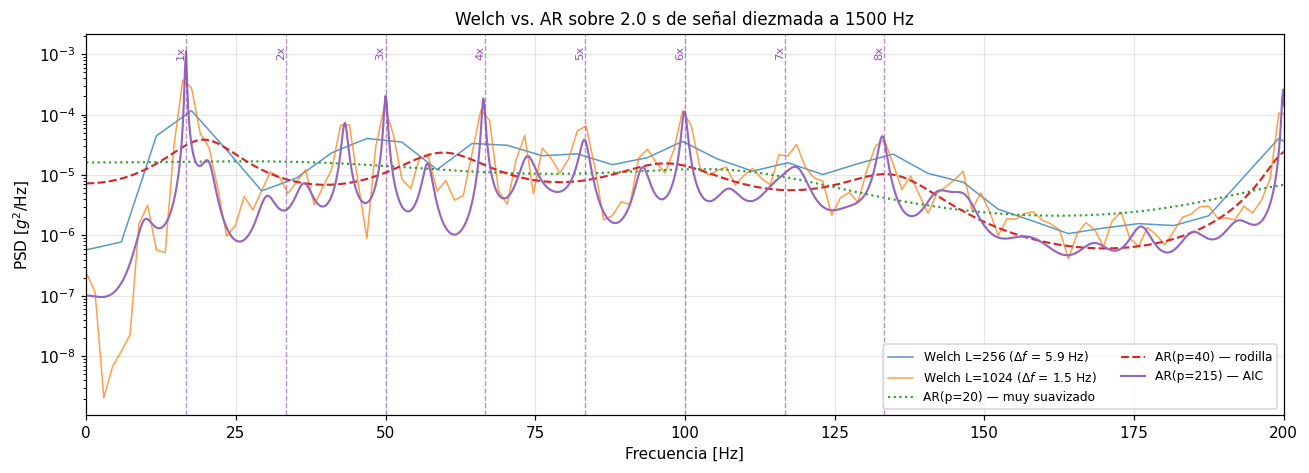

In [114]:
fig, ax = plt.subplots(figsize=(12, 4.4))
for L, est in [(256, "Welch L=256"), (1024, "Welch L=1024")]:
    if L <= N:
        fw, Pw = signal.welch(xs, fsd, nperseg=L, noverlap=L // 2)
        ax.semilogy(fw, Pw, lw=1.0, alpha=0.75,
                    label=f"{est} ($\\Delta f$ = {fsd/L:.1f} Hz)")

for p, ls, etq in [(20, ":", "muy suavizado"), (p_opt, "--", "rodilla"),
                   (p_aic, "-", "AIC")]:
    a, s2 = ar_yule_walker(r_xs, int(p))
    fa, Pa = psd_ar(a, s2, fsd)
    ax.semilogy(fa, Pa, ls, lw=1.4, label=f"AR(p={p}) — {etq}")

marcar(ax, [k * fr for k in range(1, 9)], [f"{k}x" for k in range(1, 9)], color="#8e44ad")
ax.set(xlabel="Frecuencia [Hz]", ylabel=r"PSD [$g^2$/Hz]", xlim=(0, 200),
       title=f"Welch vs. AR sobre {T_CORTO} s de señal diezmada a {fsd:.0f} Hz")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

**Lectura.** Con sólo 2 s de registro, Welch con $L=256$ ($\Delta f = 5.9$ Hz) no separa
los armónicos de $f_r$, que están espaciados apenas 16.7 Hz; al subir a $L=1024$
($\Delta f = 1.5$ Hz) los resuelve, pero quedan tan pocos segmentos que la estimación se
vuelve visiblemente ruidosa — el compromiso sesgo/varianza en estado puro.

**Y el veredicto entre los dos criterios de orden es claro: gana el AIC.** El modelo
AR(215) reproduce los armónicos de $f_r$ con una curva mucho más suave que Welch $L=1024$ a
resolución comparable — concentra cada componente en un par de polos en lugar de repartir
resolución uniformemente sobre todo el eje. En cambio AR(40), el orden que sugería el
criterio de la rodilla, **borra los armónicos por completo**: da sólo la envolvente
espectral. Y AR(20), todavía menos.

La razón es instructiva. La rodilla de $\sigma_w^2(p)$ sigue el ajuste de la parte
**de banda ancha**, que satura con pocos polos; los armónicos aportan una fracción mínima de
la varianza total, así que el criterio es ciego a ellos justo cuando son lo único que
interesa. Un criterio de orden basado en el error de predicción optimiza el ajuste global,
no la resolución de la estructura fina. Conviene recordarlo antes de confiar en él: **el
orden "óptimo" depende de para qué se quiere el modelo.**

Con todo, esto ilustra la ventaja real de los métodos paramétricos —resolución con registros
cortos— pero también deja claro por qué no resuelven el problema de fondo: el AR mejora la
lectura de las componentes sincrónicas, que ya sabíamos que estaban, y no hace aparecer la
frecuencia de falla, que sigue enmascarada. Para eso hace falta demodular.

---

# 5. Selección automática de la banda de demodulación: kurtograma rápido

### El problema

El análisis de envolvente requiere elegir una banda pasabanda antes de demodular. Esa
elección **determina el resultado**: si se demodula una banda donde no hay impactos, el
espectro de envolvente sale vacío aunque la falla exista. La práctica habitual es elegirla a
ojo sobre el *hump* de resonancia, lo que es subjetivo y no reproducible.

### La kurtosis espectral

Antoni propone medir, para cada frecuencia, cuán impulsiva es la señal **en esa banda**. Si
$X(t,f)$ es la representación tiempo-frecuencia (envolvente compleja de la banda centrada
en $f$), la kurtosis espectral es

$$K(f) \;=\; \frac{\left\langle |X(t,f)|^4 \right\rangle_t}
{\left\langle |X(t,f)|^2 \right\rangle_t^{2}} \;-\; 2$$

El $-2$ centra el indicador: para un proceso **gaussiano complejo circular estacionario**,
$|X|^2$ es exponencial y $\mathbb{E}|X|^4 = 2\,(\mathbb{E}|X|^2)^2$, de modo que $K(f)=0$.
Por lo tanto:

- $K(f) \approx 0$ &rarr; la banda contiene ruido o vibración estacionaria;
- $K(f) > 0$ &rarr; la banda contiene transitorios que aparecen y desaparecen — impactos.

### El kurtograma y su versión rápida

$K(f)$ depende del ancho de banda del análisis: una banda demasiado ancha promedia el
impacto con todo lo demás, y una demasiado angosta alarga la respuesta al impulso del
filtro por encima del intervalo entre impactos y los fusiona. El **kurtograma** evalúa
$K(f)$ en un plano (frecuencia central, ancho de banda) y toma el máximo.

El algoritmo rápido explota que, si $X(f)$ es la FFT de la señal completa, extraer un
bloque contiguo de $L$ bines y antitransformarlo da directamente la **envolvente compleja
diezmada** de esa banda, con un costo de $O(L\log L)$. Recorrer todas las bandas de un nivel
cuesta entonces $O(N\log N)$ en total, y el árbol completo de $K$ niveles, $O(K N\log N)$.
Se usa el árbol *1/3-binario* de Antoni, que alterna divisiones en $2^k$ y $3\cdot 2^{k-1}$
bandas para cubrir mejor el eje de anchos de banda.

### Dos cuidados imprescindibles

La kurtosis espectral es un cociente: mide **contraste**, no energía. Eso la vuelve
sensible a bandas donde no hay prácticamente nada, y obliga a acotar el espacio de búsqueda.

1. **Bandas sin energía útil.** Una banda casi vacía puede dar una kurtosis enorme sólo
   porque el cociente se normaliza por una potencia media minúscula. El caso extremo está
   en estos mismos datos: aplicado al **registro de ruido**, el kurtograma devuelve
   $SK \approx 244$ — un valor dos órdenes de magnitud mayor que el del canal con falla —
   producido íntegramente por el único *glitch* del paso 2 en una banda donde no hay señal
   alguna. Un detector que se guiara por el máximo de SK diría que el sensor desconectado
   es el componente más dañado de la planta. Se exige entonces que la potencia de la banda
   supere el piso de ruido del paso 2 por un margen mínimo.
2. **Bordes del espectro.** La cadena de adquisición tiene un filtro antialias: cerca de
   Nyquist la señal está fuertemente atenuada y lo que queda es ruido de cuantización no
   estacionario. Es un caso particular del problema anterior, pero conviene acotarlo
   explícitamente porque la atenuación es progresiva y la guarda de energía puede no
   alcanzar. Se descarta el 10 % superior del eje. También se descarta por abajo la zona
   de órdenes de eje ($< 500$ Hz), que no corresponde a ninguna resonancia estructural.

In [115]:
def niveles_arbol(nlevel):
    # Arbol 1/3-binario: niveles con 2^k y 3*2^(k-1) bandas.
    ls = []
    for k in range(1, nlevel + 1):
        ls.append((float(k), 2 ** k))
        ls.append((k + np.log2(3) - 1, 3 * 2 ** (k - 1)))
    return sorted(ls)


def kurtograma(x, fs, nlevel=7, f_min=0.0, f_max_frac=1.0,
               psd_ruido=None, f_ruido=None, margen_db=6.0):
    # Kurtograma rapido. Devuelve la lista de niveles con su vector de SK.
    # Cada banda se obtiene extrayendo un bloque contiguo de la FFT y antitransformando:
    # eso da la envolvente compleja diezmada de la banda, sin filtrar explicitamente.
    X = np.fft.rfft(np.asarray(x, float))
    M = len(X) - 1                      # bines utiles (se excluye la continua)
    nyq = fs / 2
    filas = []
    for lvl, nb in niveles_arbol(nlevel):
        B = nyq / nb
        sk = np.full(nb, np.nan)
        pot = np.full(nb, np.nan)
        bordes = np.round(np.linspace(0, M, nb + 1)).astype(int)
        fc = (np.arange(nb) + 0.5) * B
        for j in range(nb):
            i1, i2 = bordes[j] + 1, bordes[j + 1] + 1
            if i2 - i1 < 16:            # muy pocas muestras -> estimador inestable
                continue
            if fc[j] < f_min or fc[j] > f_max_frac * nyq:
                continue
            z = np.fft.ifft(X[i1:i2])   # envolvente compleja diezmada de la banda
            a2 = np.abs(z) ** 2
            m2 = a2.mean()
            if m2 <= 0:
                continue
            pot[j] = m2
            if psd_ruido is not None:
                p_rui = np.interp(fc[j], f_ruido, psd_ruido) * B   # potencia de ruido
                if m2 < p_rui * 10 ** (margen_db / 10):
                    continue            # banda sin energia util
            sk[j] = (a2 ** 2).mean() / m2 ** 2 - 2.0
        filas.append({"lvl": lvl, "nb": nb, "B": B, "fc": fc, "sk": sk, "pot": pot})
    return filas


def mejor_banda(filas):
    mejor = None
    for r in filas:
        if np.all(np.isnan(r["sk"])):
            continue
        j = int(np.nanargmax(r["sk"]))
        if mejor is None or r["sk"][j] > mejor["SK"]:
            mejor = {"SK": float(r["sk"][j]), "fc": float(r["fc"][j]),
                     "B": float(r["B"]), "nivel": r["lvl"], "nb": r["nb"]}
    mejor["banda"] = (mejor["fc"] - mejor["B"] / 2, mejor["fc"] + mejor["B"] / 2)
    return mejor


def dibujar_kurtograma(filas, fs, ax, titulo):
    # Rasteriza los niveles sobre una grilla comun de frecuencia.
    nf = 1024
    fg = np.linspace(0, fs / 2, nf)
    img = np.full((len(filas), nf), np.nan)
    for i, r in enumerate(filas):
        idx = np.clip((fg / r["B"]).astype(int), 0, r["nb"] - 1)
        img[i] = r["sk"][idx]
    im = ax.imshow(img, aspect="auto", origin="lower", cmap="inferno",
                   extent=[0, fs / 2, -0.5, len(filas) - 0.5])
    ax.set_yticks(range(len(filas)))
    ax.set_yticklabels([f"{r['lvl']:.1f}  ({r['B']:.0f} Hz)" for r in filas], fontsize=7)
    ax.set(xlabel="Frecuencia central [Hz]", ylabel="nivel  (ancho de banda)",
           title=titulo)
    ax.grid(False)
    return im


print("kurtograma definido")

kurtograma definido


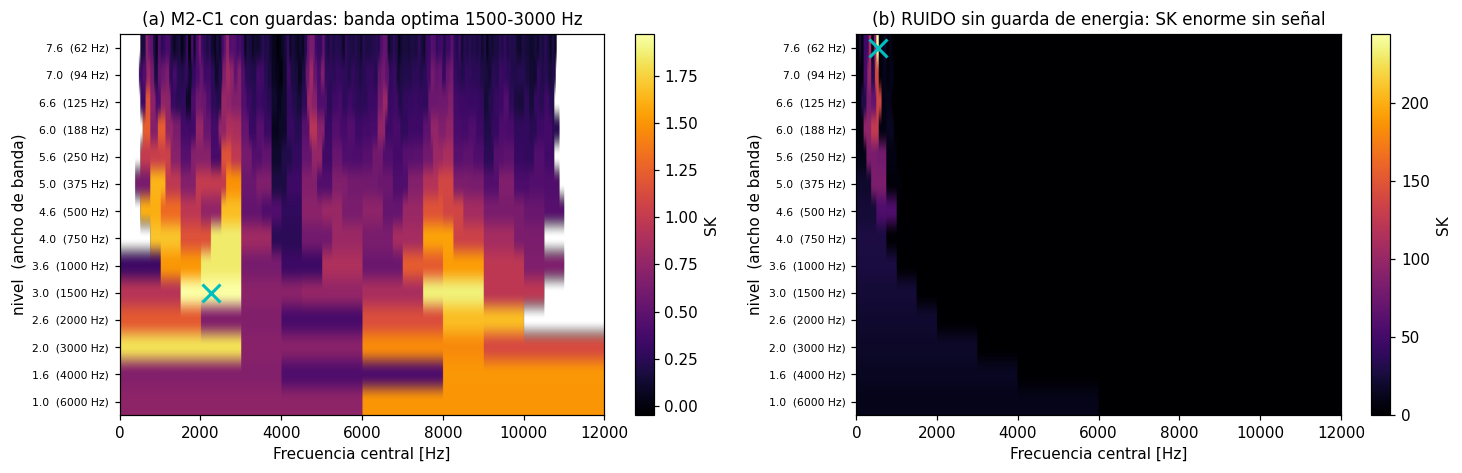

(a) M2-C1, con guardas : SK = 1.97 en fc = 2250 Hz, B = 1500 Hz -> banda [1500, 3000] Hz
(b) RUIDO, sin guardas : SK = 243.86 en fc = 531 Hz, B = 62 Hz   <-- 124 veces el SK del canal con falla, producido por un solo glitch

M2-C1 sin guardas      : SK = 1.97 en fc = 2250 Hz, B = 1500 Hz -> MISMA banda


In [116]:
NLEVEL = 7
KURT_FMIN = 500.0        # descarta la zona de ordenes de eje (no es una resonancia)
KURT_FMAXF = 0.90        # descarta el borde de Nyquist (filtro antialias)

x_falla = CH["M2-C1"]["x"]

# --- (a) el canal bajo estudio, con guardas ---
k_falla = kurtograma(x_falla, FS_ACEL, nlevel=NLEVEL, f_min=KURT_FMIN,
                     f_max_frac=KURT_FMAXF, psd_ruido=PSD_RUIDO, f_ruido=F_RUIDO)
b_falla = mejor_banda(k_falla)

# --- (b) el registro de RUIDO sin la guarda de energia: el artefacto ---
k_rui = kurtograma(CH["RUIDO"]["x"], FS_ACEL, nlevel=NLEVEL, f_min=0.0, f_max_frac=1.0)
b_rui = mejor_banda(k_rui)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))
im = dibujar_kurtograma(k_falla, FS_ACEL, ax[0],
                        f"(a) M2-C1 con guardas: banda optima "
                        f"{b_falla['banda'][0]:.0f}-{b_falla['banda'][1]:.0f} Hz")
ax[0].plot(b_falla["fc"], [r["lvl"] for r in k_falla].index(b_falla["nivel"]),
           "cx", ms=12, mew=2)
fig.colorbar(im, ax=ax[0], label="SK")

im = dibujar_kurtograma(k_rui, FS_ACEL, ax[1],
                        "(b) RUIDO sin guarda de energia: SK enorme sin señal")
ax[1].plot(b_rui["fc"], [r["lvl"] for r in k_rui].index(b_rui["nivel"]),
           "cx", ms=12, mew=2)
fig.colorbar(im, ax=ax[1], label="SK")
fig.tight_layout()
plt.show()

print(f"(a) M2-C1, con guardas : SK = {b_falla['SK']:.2f} en fc = {b_falla['fc']:.0f} Hz, "
      f"B = {b_falla['B']:.0f} Hz -> banda "
      f"[{b_falla['banda'][0]:.0f}, {b_falla['banda'][1]:.0f}] Hz")
print(f"(b) RUIDO, sin guardas : SK = {b_rui['SK']:.2f} en fc = {b_rui['fc']:.0f} Hz, "
      f"B = {b_rui['B']:.0f} Hz   <-- {b_rui['SK']/b_falla['SK']:.0f} veces el SK del "
      f"canal con falla, producido por un solo glitch")

# robustez: el optimo de M2-C1 no depende de las guardas
b_falla_sin = mejor_banda(kurtograma(x_falla, FS_ACEL, nlevel=NLEVEL,
                                     f_min=0.0, f_max_frac=1.0))
print(f"\nM2-C1 sin guardas      : SK = {b_falla_sin['SK']:.2f} en fc = "
      f"{b_falla_sin['fc']:.0f} Hz, B = {b_falla_sin['B']:.0f} Hz "
      f"-> {'MISMA banda' if abs(b_falla_sin['fc']-b_falla['fc']) < 1 else 'banda distinta'}")

BANDA = b_falla["banda"]

**Lectura de los dos paneles.** En (a), el kurtograma de M2-C1 señala una banda física en la
zona de los kHz — exactamente el *hump* de resonancia que se intuía en la PSD del paso 4.
Ésta es la **justificación cuantitativa** de la banda de demodulación, en lugar de una
elección visual.

En (b) está el artefacto: el registro de **ruido**, sin la guarda de energía, alcanza un SK
dos órdenes de magnitud mayor que el del canal realmente fallado, en una banda angosta de
baja frecuencia donde no hay señal alguna. Todo ese valor proviene del único *glitch*
localizado en el paso 2. Es la demostración concreta de que **el máximo de SK no es un
indicador de falla**: es un indicador de contraste, y el contraste puede venir de la
ausencia de señal tanto como de su presencia.

Conviene destacar también que, para M2-C1, las guardas **no cambian el resultado**: la banda
óptima es la misma con y sin restricciones. Las guardas no están sesgando la respuesta hacia
donde queremos; están descartando regiones donde la pregunta no tiene sentido.

In [117]:
# El mismo procedimiento aplicado a todos los canales, para comparar.
KURT = {}
for clave, d in CH.items():
    filas = kurtograma(d["x"], d["fs"], nlevel=NLEVEL, f_min=KURT_FMIN,
                       f_max_frac=KURT_FMAXF, psd_ruido=PSD_RUIDO, f_ruido=F_RUIDO)
    KURT[clave] = mejor_banda(filas)

res = pd.DataFrame(KURT).T[["SK", "fc", "B"]]
res["banda [Hz]"] = [f"{v['banda'][0]:.0f} - {v['banda'][1]:.0f}" for v in KURT.values()]
res.columns = ["SK max", "fc [Hz]", "B [Hz]", "banda [Hz]"]
display(res.style.format({"SK max": "{:.2f}", "fc [Hz]": "{:.0f}", "B [Hz]": "{:.0f}"}))

,SK max,fc [Hz],B [Hz],banda [Hz]
M2-C1,1.97,2250,1500,1500 - 3000
M2-C2,1.88,937,375,750 - 1125
M1-C1,4.46,8625,750,8250 - 9000
M1-C2,7.53,10000,4000,8000 - 12000
RUIDO,243.86,531,62,500 - 562


> **Advertencia metodológica.** Una kurtosis espectral alta **no es por sí sola un
> diagnóstico de falla**, y la tabla anterior lo muestra sin ambigüedad: los canales de
> referencia M1-C1 y M1-C2 alcanzan un $SK$ de $4.5$ y $7.5$ — **mayor** que el $1.97$ del
> canal efectivamente fallado. El kurtograma sólo dice "en esta banda hay algo no
> estacionario"; puede ser una falla de rodamiento, pero también rozamiento, cavitación,
> holgura, flujo turbulento o un artefacto de la cadena de medición.
>
> Lo que convierte el indicio en diagnóstico es el **paso siguiente**: demodular esa banda y
> comprobar si la envolvente contiene una periodicidad a una frecuencia compatible con una
> frecuencia de paso del rodamiento, con armónicos y bandas laterales. El kurtograma
> selecciona *dónde mirar*; el espectro de envolvente dice *qué hay*. Ordenar los canales
> por $SK$ daría, otra vez, el ranking equivocado — igual que el RMS en el paso 3.

---

# 6. Análisis de envolvente

### El modelo de señal

Una falla localizada en una pista produce, cada vez que un rodillo pasa por el defecto, un
impacto de muy corta duración. La estructura responde a cada impacto con su respuesta
impulsiva $h(t)$, una oscilación amortiguada a la frecuencia de resonancia $f_{\text{res}}$.
La señal medida es aproximadamente

$$x(t) \;\approx\; \sum_{i} A_i\; h\!\left(t - i\,T_d - \tau_i\right) \;+\; n(t)$$

donde $T_d = 1/f_d$ es el intervalo entre impactos ($f_d$ = frecuencia de paso del defecto),
$\tau_i$ es una fluctuación aleatoria pequeña debida al **deslizamiento** de los rodillos, y
$A_i$ modula la amplitud según la posición del defecto respecto de la zona de carga.

Es decir: **la información de la falla está en la envolvente, no en la portadora**. La
portadora es $f_{\text{res}}$ (kHz); la modulante es $f_d$ (decenas o centenas de Hz).

### Demodulación por transformada de Hilbert

Se construye la señal analítica a partir de la señal filtrada $x_b(t)$:

$$z(t) = x_b(t) + j\,\mathcal{H}\{x_b\}(t),
\qquad
\mathcal{H}\{x_b\}(t) = \frac{1}{\pi}\,\text{v.p.}\!\!\int_{-\infty}^{\infty}
\frac{x_b(\tau)}{t-\tau}\,d\tau$$

En frecuencia, $\mathcal{H}$ es un filtro de módulo unitario que desfasa $-90^\circ$ las
frecuencias positivas y $+90^\circ$ las negativas; $Z(f)$ conserva sólo las frecuencias
positivas, duplicadas. La envolvente instantánea es $e(t) = |z(t)|$.

Al calcular la PSD de $e(t)$ —tras restarle su valor medio, que si no domina como una
delta en continua— la periodicidad de los impactos aparece **trasladada a baja frecuencia**,
y con ella sus armónicos.

### Por qué una falla en pista interna tiene bandas laterales a $\pm f_r$

La pista interna gira solidaria al eje. El defecto, por lo tanto, **gira**: pasa una vez por
vuelta por la zona de máxima carga (donde el impacto es fuerte) y media vuelta después por
la zona descargada (donde es débil). La amplitud de los impactos queda entonces modulada a
la frecuencia de giro:

$$e(t) \;\propto\; \underbrace{\left[1 + m\cos(2\pi f_r t)\right]}_{\text{modulación por zona de carga}}
\cdot \underbrace{\sum_i \delta(t - i/f_{\text{BPFI}})}_{\text{tren de impactos}}$$

y el producto en el tiempo es convolución en frecuencia: cada armónico $k\cdot f_{\text{BPFI}}$
aparece flanqueado por **bandas laterales** en $k\cdot f_{\text{BPFI}} \pm f_r$. Ésta es la
firma distintiva de la falla en pista interna, y es lo que la separa de una falla en pista
externa (que, siendo fija respecto de la carga, **no** genera esas bandas laterales).

In [118]:
# ENV : cada canal demodulado en SU PROPIA banda optima (procedimiento automatico completo)
# ENVC: todos los canales demodulados en la MISMA banda, la del canal bajo estudio.
#       Esta ultima es la que permite comparar: pregunta si hay energia a f_BPFI en la
#       banda de resonancia de interes, con parametros identicos para todos.
ENV, ENVC = {}, {}
for clave, d in CH.items():
    banda = KURT[clave]["banda"]
    f_e, P_e, env, y_b = espectro_envolvente(d["x"], d["fs"], banda)
    ENV[clave] = {"f": f_e, "P": P_e, "env": env, "filtrada": y_b, "banda": banda}

    f_c, P_c, env_c, y_c = espectro_envolvente(d["x"], d["fs"], BANDA)
    ENVC[clave] = {"f": f_c, "P": P_c, "env": env_c, "filtrada": y_c, "banda": BANDA}

claves_maq = [k for k in CH if k != "RUIDO"]

# Pico dominante provisorio, para poder anotar los graficos que siguen. El paso 7 lo
# vuelve a calcular con el procedimiento formal y reporta la evidencia que lo sostiene.
_f, _P = ENVC["M2-C1"]["f"], ENVC["M2-C1"]["P"]
_m = (_f >= 2 * fr) & (_f <= 15 * fr)
f_pico_prov = float(_f[_m][np.argmax(_P[_m])])

print(f"Resolucion del espectro de envolvente: {ENV['M2-C1']['f'][1]:.3f} Hz "
      f"(fr / {fr/ENV['M2-C1']['f'][1]:.0f})")
print(f"Banda comun de comparacion: {BANDA[0]:.0f} - {BANDA[1]:.0f} Hz")
print(f"Pico dominante provisorio en M2-C1: {f_pico_prov:.2f} Hz "
      f"-> periodo entre impactos {1000/f_pico_prov:.2f} ms")

Resolucion del espectro de envolvente: 0.366 Hz (fr / 46)
Banda comun de comparacion: 1500 - 3000 Hz
Pico dominante provisorio en M2-C1: 173.22 Hz -> periodo entre impactos 5.77 ms


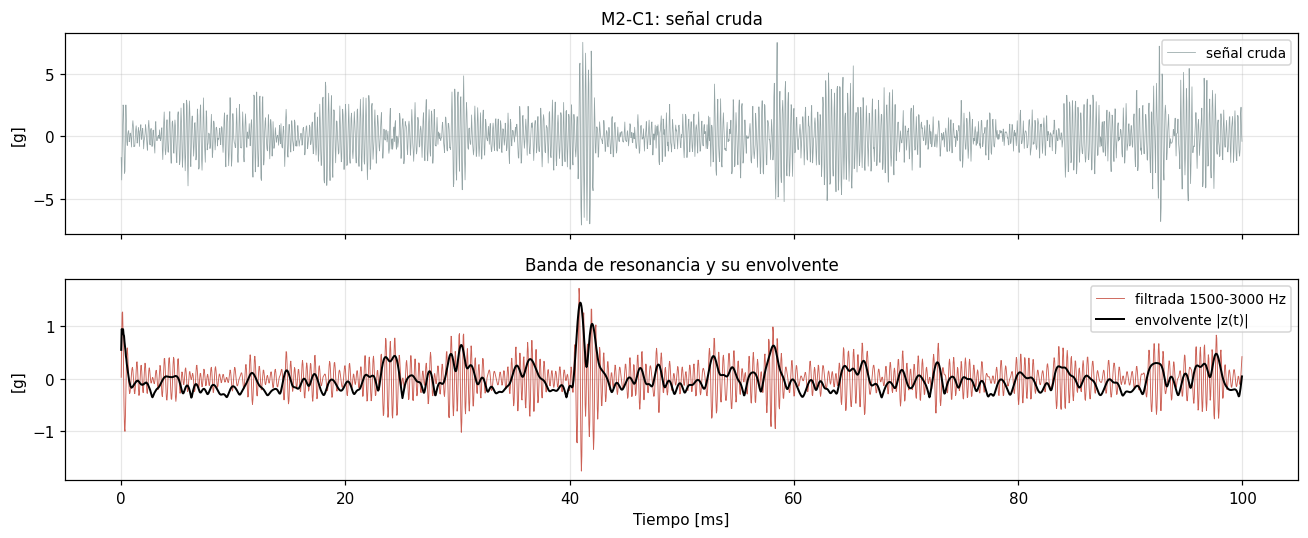

In [119]:
# Efecto de la demodulacion, en el tiempo
d = CH["M2-C1"]
e = ENV["M2-C1"]
n0, n1 = 0, int(0.10 * FS_ACEL)       # 100 ms
tt = np.arange(n0, n1) / FS_ACEL * 1e3

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(tt, d["x"][n0:n1], lw=0.5, color="#95a5a6", label="señal cruda")
ax[0].set(ylabel="[g]", title="M2-C1: señal cruda")
ax[0].legend(loc="upper right")

ax[1].plot(tt, e["filtrada"][n0:n1], lw=0.6, color=COLOR["falla"], alpha=0.8,
           label=f"filtrada {e['banda'][0]:.0f}-{e['banda'][1]:.0f} Hz")
ax[1].plot(tt, e["env"][n0:n1] + e["env"].mean(), lw=1.3, color="k",
           label="envolvente |z(t)|")
ax[1].set(xlabel="Tiempo [ms]", ylabel="[g]",
          title="Banda de resonancia y su envolvente")
ax[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

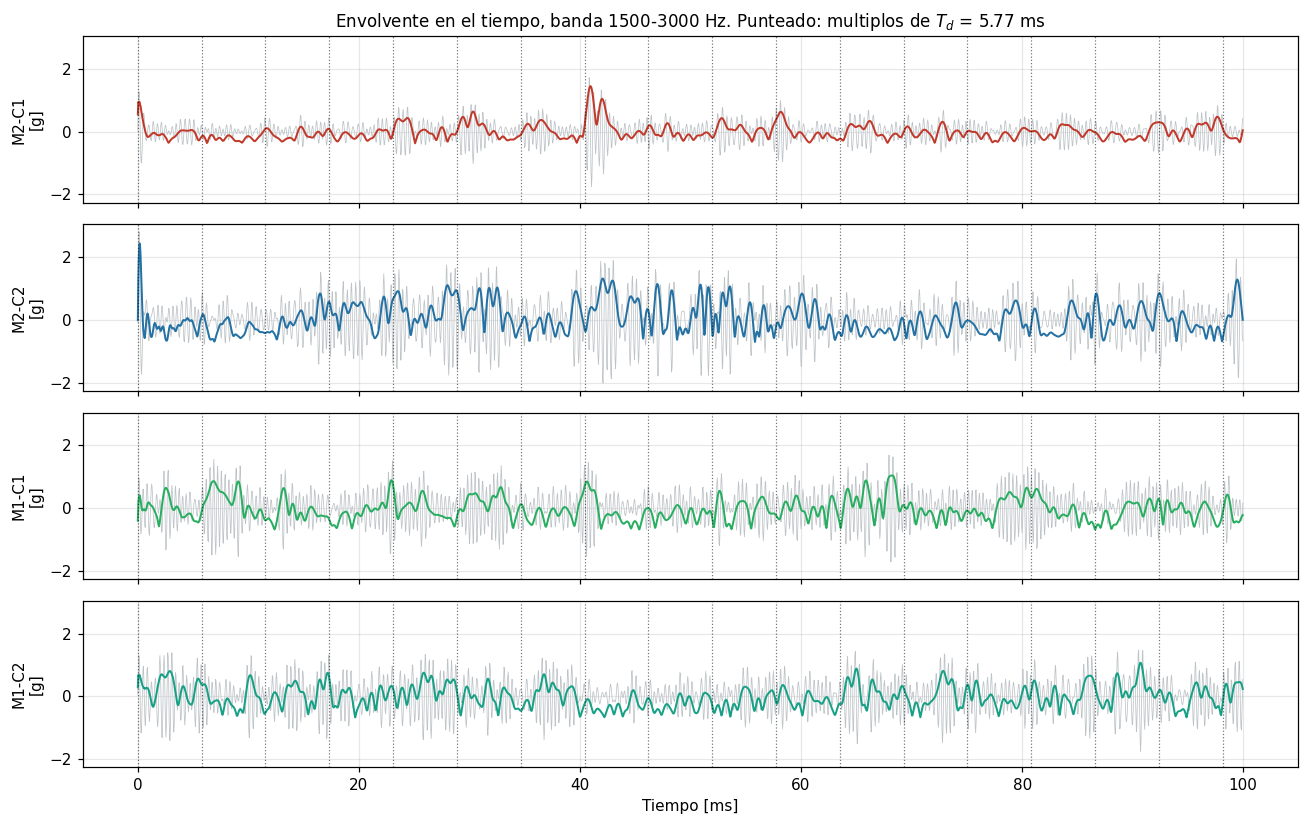

In [120]:
# --- la envolvente en el TIEMPO, los cuatro canales en la misma banda y misma escala ---
n0, n1 = 0, int(0.10 * FS_ACEL)
tt = np.arange(n0, n1) / FS_ACEL * 1e3
Td_ms = 1000.0 / f_pico_prov          # periodo entre impactos esperado

fig, axes = plt.subplots(len(claves_maq), 1, figsize=(12, 1.9 * len(claves_maq)),
                         sharex=True, sharey=True)
for a, clave in zip(axes, claves_maq):
    e = ENVC[clave]
    a.plot(tt, e["filtrada"][n0:n1], lw=0.5, color="#bdc3c7")
    a.plot(tt, e["env"][n0:n1] + e["env"].mean(), lw=1.3, color=COLOR[CH[clave]["rol"]])
    for k in range(int(0.10 * 1000 / Td_ms) + 1):
        a.axvline(k * Td_ms, color="k", ls=":", lw=0.8, alpha=0.55)
    a.set_ylabel(f"{clave}\n[g]")
axes[0].set_title(f"Envolvente en el tiempo, banda {BANDA[0]:.0f}-{BANDA[1]:.0f} Hz. "
                  f"Punteado: multiplos de $T_d$ = {Td_ms:.2f} ms")
axes[-1].set_xlabel("Tiempo [ms]")
fig.tight_layout()
plt.show()

Acá se ve el fenómeno directamente en el tiempo, antes de cualquier transformada. En M2-C1
la envolvente (línea gruesa) tiene **picos regulares** que caen sobre las líneas punteadas,
separadas $T_d = 5.8$ ms. En los tres canales de referencia la envolvente fluctúa sin
estructura: sube y baja de forma aleatoria, como corresponde a una banda de ruido filtrado.

Ésa es toda la física del método. Lo que sigue —espectro de la envolvente, kurtograma,
wavelets— son herramientas para **medir** esa periodicidad de forma objetiva y automática,
pero el fenómeno ya está a la vista.

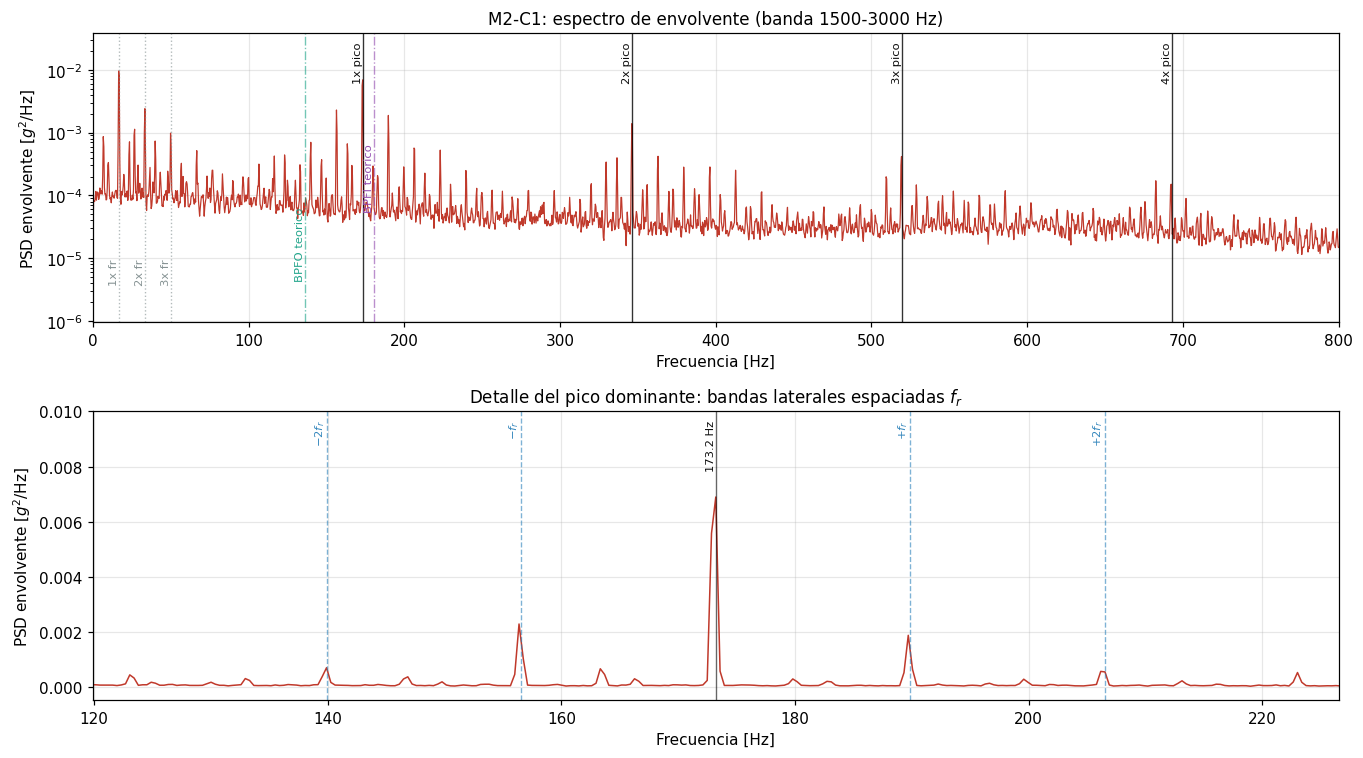

Pico dominante: 173.22 Hz = 10.396 x fr


In [121]:
# --- espectro de envolvente del canal con falla, anotado ---
f_e, P_e = ENV["M2-C1"]["f"], ENV["M2-C1"]["P"]

# pico dominante empirico en 2*fr .. 15*fr (ver paso 7)
msk = (f_e >= 2 * fr) & (f_e <= 15 * fr)
f_pico = float(f_e[msk][np.argmax(P_e[msk])])

fig, ax = plt.subplots(2, 1, figsize=(12.5, 7))

ax[0].plot(f_e, P_e, lw=0.8, color=COLOR["falla"])
marcar(ax[0], [k * f_pico for k in range(1, 5)],
       [f"{k}x pico" for k in range(1, 5)], color="k", ls="-", alpha=0.8, y_rel=0.97)
marcar(ax[0], [TEO["BPFI"]], ["BPFI teorico"], color="#8e44ad", ls="-.", y_rel=0.62)
marcar(ax[0], [TEO["BPFO"]], ["BPFO teorico"], color="#16a085", ls="-.", y_rel=0.40)
marcar(ax[0], [k * fr for k in range(1, 4)], [f"{k}x fr" for k in range(1, 4)],
       color="#7f8c8d", ls=":", y_rel=0.22)
ax[0].set(xlabel="Frecuencia [Hz]", ylabel=r"PSD envolvente [$g^2$/Hz]",
          xlim=(0, 800), yscale="log",
          ylim=(P_e[f_e > 1].max() * 1e-4, P_e[f_e > 1].max() * 4),
          title=f"M2-C1: espectro de envolvente (banda {ENV['M2-C1']['banda'][0]:.0f}"
                f"-{ENV['M2-C1']['banda'][1]:.0f} Hz)")

# zoom en el primer armonico, para ver las bandas laterales
ax[1].plot(f_e, P_e, lw=1.0, color=COLOR["falla"])
marcar(ax[1], [f_pico], [f"{f_pico:.1f} Hz"], color="k", ls="-")
marcar(ax[1], [f_pico - 2 * fr, f_pico - fr, f_pico + fr, f_pico + 2 * fr],
       [r"$-2f_r$", r"$-f_r$", r"$+f_r$", r"$+2f_r$"], color="#2980b9", ls="--")
ax[1].set(xlabel="Frecuencia [Hz]", ylabel=r"PSD envolvente [$g^2$/Hz]",
          xlim=(f_pico - 3.2 * fr, f_pico + 3.2 * fr),
          title="Detalle del pico dominante: bandas laterales espaciadas $f_r$")
fig.tight_layout()
plt.show()

print(f"Pico dominante: {f_pico:.2f} Hz = {f_pico/fr:.3f} x fr")

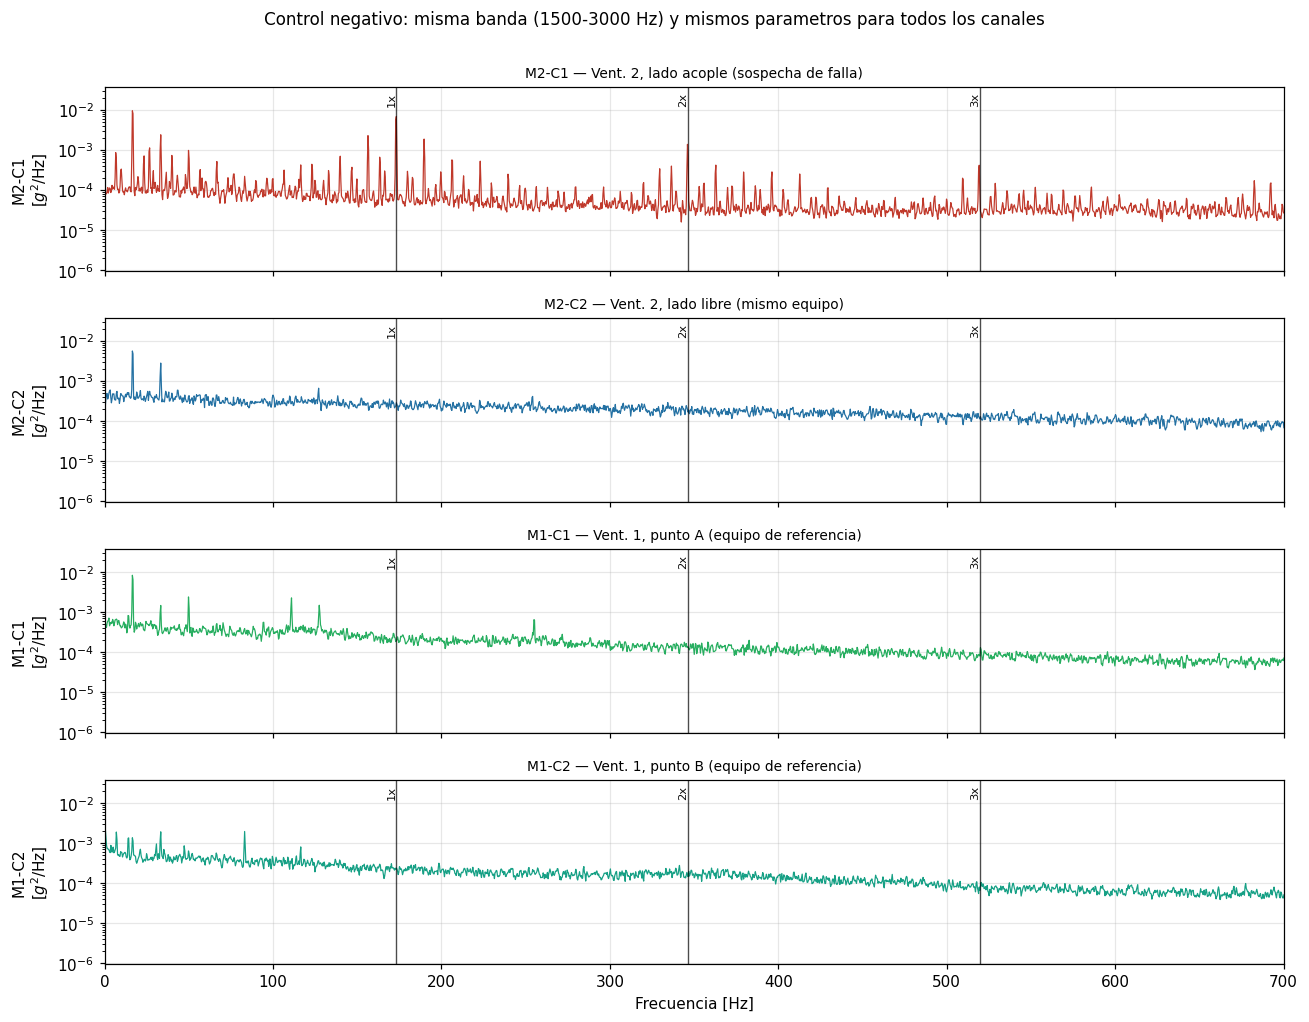

Relacion pico/fondo a 173.2 Hz, por canal:
  M2-C1 :  20.6 dB
  M2-C2 :   1.4 dB
  M1-C1 :   1.3 dB
  M1-C2 :   1.3 dB


In [122]:
# --- control negativo: los demas canales, en la MISMA banda y con los mismos parametros ---
# escala vertical COMUN a los cuatro paneles, para que la comparacion sea directa
_tope = max(ENVC[k]["P"][ENVC[k]["f"] > 1].max() for k in claves_maq)
YLIM = (_tope * 1e-4, _tope * 4)

fig, ax = plt.subplots(len(claves_maq), 1, figsize=(12, 2.3 * len(claves_maq)),
                       sharex=True, sharey=True)
for a, clave in zip(ax, claves_maq):
    e = ENVC[clave]
    a.plot(e["f"], e["P"], lw=0.8, color=COLOR[CH[clave]["rol"]])
    marcar(a, [k * f_pico for k in range(1, 4)],
           [f"{k}x" for k in range(1, 4)], color="k", ls="-", alpha=0.7)
    a.set(ylabel=f"{clave}\n" + r"[$g^2$/Hz]", yscale="log", xlim=(0, 700), ylim=YLIM)
    a.set_title(f"{clave} — {CH[clave]['desc']}", fontsize=9)
ax[-1].set_xlabel("Frecuencia [Hz]")
fig.suptitle(f"Control negativo: misma banda ({BANDA[0]:.0f}-{BANDA[1]:.0f} Hz) y "
             f"mismos parametros para todos los canales", y=1.005, fontsize=11)
fig.tight_layout()
plt.show()

print(f"Relacion pico/fondo a {f_pico:.1f} Hz, por canal:")
tol_c = max(0.03 * f_pico, 3 * (ENVC['M2-C1']['f'][1] - ENVC['M2-C1']['f'][0]))
for clave in claves_maq:
    _, _, s = pico_cerca(ENVC[clave]["f"], ENVC[clave]["P"], f_pico, tol_c)
    print(f"  {clave:<6}: {s:5.1f} dB")

La diferencia es categórica: sólo M2-C1 presenta una serie armónica en $173$ Hz, unos 20 dB
sobre el fondo local, mientras que los canales de referencia se quedan en 1–2 dB, es decir,
indistinguibles del fondo. Los cuatro canales fueron procesados con **exactamente los mismos
parámetros**: misma banda, mismo filtro, misma demodulación, misma estimación espectral.
Esto descarta que el resultado sea un artefacto del procesamiento.

(Demodular cada canal en *su propio* óptimo del kurtograma —las bandas distintas de la
tabla del paso 5— lleva a la misma conclusión: ninguno de los canales de referencia
muestra una serie armónica a un múltiplo no entero de $f_r$.)

### Validación cruzada contra el software de mantenimiento

El sistema de monitoreo exporta también su propia envolvente (`med2_env_wf.csv`, en unidades
gE, muestreada a 3 kHz). Su algoritmo interno es propietario —banda de filtrado y método de
demodulación desconocidos— pero si nuestra cadena es correcta, ambos espectros deben
coincidir en las frecuencias de los picos, aunque no necesariamente en las amplitudes.

Es una verificación independiente del pipeline completo: carga, escalado, filtrado, Hilbert
y estimación espectral.

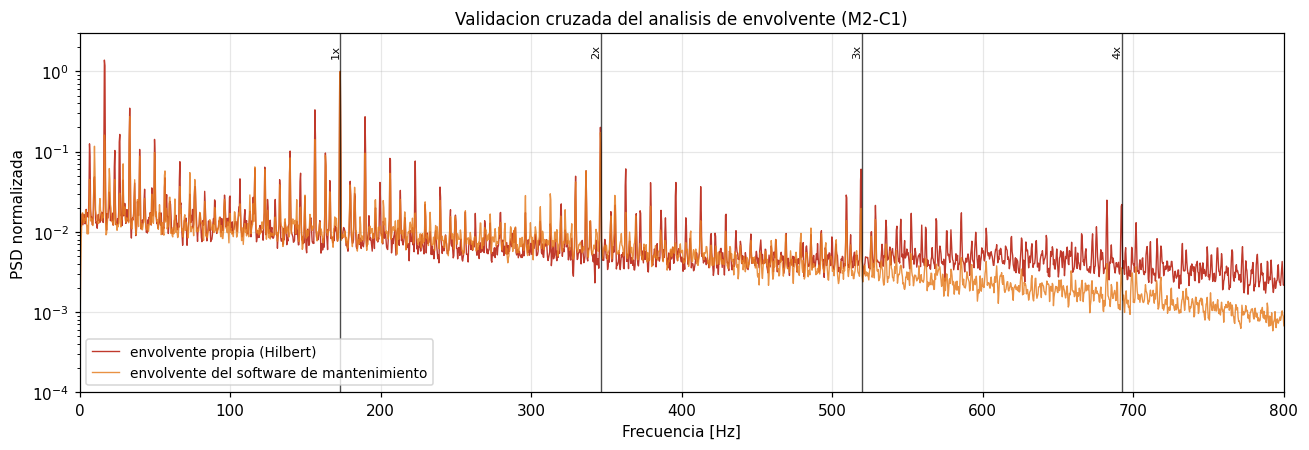

Pico dominante, envolvente propia   : 173.22 Hz
Pico dominante, envolvente del equipo: 173.22 Hz
Discrepancia: 0.00 Hz (0.00 %, resolucion del equipo 0.37 Hz)


In [123]:
_, E, fse, _ = cargar_wf("med2_env_wf.csv", FS_LF, t_max=T_ANALISIS)
env_sw = preparar(E[:, 0])                       # canal 1, el del lado acople
f_sw, P_sw = signal.welch(env_sw, fse, nperseg=2 ** 13, noverlap=2 ** 12)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.semilogy(f_e, P_e / P_e[(f_e > 2 * fr) & (f_e < 15 * fr)].max(),
            lw=0.9, color=COLOR["falla"], label="envolvente propia (Hilbert)")
ax.semilogy(f_sw, P_sw / P_sw[(f_sw > 2 * fr) & (f_sw < 15 * fr)].max(),
            lw=0.9, color="#e67e22", alpha=0.85,
            label="envolvente del software de mantenimiento")
marcar(ax, [k * f_pico for k in range(1, 5)], [f"{k}x" for k in range(1, 5)],
       color="k", ls="-", alpha=0.7)
ax.set(xlabel="Frecuencia [Hz]", ylabel="PSD normalizada", xlim=(0, 800),
       ylim=(1e-4, 3),
       title="Validacion cruzada del analisis de envolvente (M2-C1)")
ax.legend()
fig.tight_layout()
plt.show()

m_sw = (f_sw >= 2 * fr) & (f_sw <= 15 * fr)
f_pico_sw = float(f_sw[m_sw][np.argmax(P_sw[m_sw])])
print(f"Pico dominante, envolvente propia   : {f_pico:.2f} Hz")
print(f"Pico dominante, envolvente del equipo: {f_pico_sw:.2f} Hz")
print(f"Discrepancia: {abs(f_pico-f_pico_sw):.2f} Hz "
      f"({100*abs(f_pico-f_pico_sw)/f_pico:.2f} %, resolucion del equipo "
      f"{f_sw[1]-f_sw[0]:.2f} Hz)")

---

# 7. Identificación empírica de la falla

Este es el paso central del trabajo. La pregunta es: **¿qué elemento del rodamiento está
fallado?** — respondida a partir de la señal, sin suponer la geometría interna.

El criterio se apoya en tres evidencias, en orden de fuerza:

1. **La relación $f_{\text{pico}}/f_r$.** Las frecuencias de falla son múltiplos **no
   enteros** de la velocidad de giro, determinados por la cinemática del rodamiento. Un
   múltiplo no entero excluye de entrada las fuentes sincrónicas (desbalanceo, paso de
   álabes, engranajes).
2. **La serie armónica.** Un tren de impactos periódico genera armónicos
   $2\times$, $3\times$, $4\times$ del período fundamental. Una resonancia excitada al azar,
   no.
3. **Las bandas laterales a $\pm f_r$.** Como se argumentó en el paso 6, indican que la
   fuente de los impactos **gira con el eje**: pista interna, no externa.

Recién después se contrasta contra los coeficientes del reporte SKF, y el contraste sirve
para *confirmar* la identificación, no para producirla.

> **Sobre la ventana de búsqueda.** Se busca el pico dominante entre $2f_r$ y $15 f_r$. El
> límite inferior excluye la componente $1\times$ y la continua; el superior cubre holgadamente
> el BPFI de este rodamiento ($10.82\,f_r$). Una ventana de $2$–$10\,f_r$, que sería adecuada
> para un rodamiento de bolas de 8–12 elementos, **dejaría el pico afuera** en este caso.

In [124]:
def identificar_falla(f, P, fr, f_lo_mult=2.0, f_hi_mult=15.0, n_arm=4, tol_mult=0.02):
    # Identificacion empirica: pico dominante, armonicos y bandas laterales a +-fr.
    m = (f >= f_lo_mult * fr) & (f <= f_hi_mult * fr)
    f_pico = float(f[m][np.argmax(P[m])])
    tol = max(tol_mult * f_pico, 3 * (f[1] - f[0]))

    armonicos, laterales = [], []
    for k in range(1, n_arm + 1):
        fk, ak, snr = pico_cerca(f, P, k * f_pico, tol)
        armonicos.append({"k": k, "f_teorico": k * f_pico, "f_hallado": fk,
                          "SNR_dB": snr})
        for signo in (-1, +1):
            fl, al, snrl = pico_cerca(f, P, k * f_pico + signo * fr, tol)
            laterales.append({"k": k, "lado": "+fr" if signo > 0 else "-fr",
                              "f_teorico": k * f_pico + signo * fr,
                              "f_hallado": fl, "SNR_dB": snrl})
    return f_pico, pd.DataFrame(armonicos), pd.DataFrame(laterales)


f_pico, ARM, LAT = identificar_falla(f_e, P_e, fr)

print("=" * 66)
print(f"  PICO DOMINANTE DEL ESPECTRO DE ENVOLVENTE (M2-C1)")
print("=" * 66)
print(f"  f_pico = {f_pico:.2f} Hz")
print(f"  f_pico / fr = {f_pico/fr:.3f}   (fr = {fr:.3f} Hz = {fr*60:.0f} rpm)")
print(f"  Multiplo entero mas cercano: {round(f_pico/fr)}  -> desvio "
      f"{100*abs(f_pico/fr - round(f_pico/fr))/round(f_pico/fr):.1f} % "
      f"(NO es una componente sincronica)")
print("=" * 66)

print("\nSerie armonica:")
display(ARM.style.format({"f_teorico": "{:.2f}", "f_hallado": "{:.2f}",
                          "SNR_dB": "{:.1f}"}))
print("Bandas laterales a +- fr:")
display(LAT.style.format({"f_teorico": "{:.2f}", "f_hallado": "{:.2f}",
                          "SNR_dB": "{:.1f}"}))

  PICO DOMINANTE DEL ESPECTRO DE ENVOLVENTE (M2-C1)
  f_pico = 173.22 Hz
  f_pico / fr = 10.396   (fr = 16.663 Hz = 1000 rpm)
  Multiplo entero mas cercano: 10  -> desvio 4.0 % (NO es una componente sincronica)

Serie armonica:


,k,f_teorico,f_hallado,SNR_dB
0,1,173.22,173.22,20.6
1,2,346.44,346.07,15.7
2,3,519.65,519.29,11.0
3,4,692.87,692.50,7.7


Bandas laterales a +- fr:


,k,lado,f_teorico,f_hallado,SNR_dB
0,1,-fr,156.56,156.37,15.6
1,1,+fr,189.88,189.70,15.1
2,2,-fr,329.77,329.59,9.4
3,2,+fr,363.10,362.92,10.7
4,3,-fr,502.99,499.88,2.8
5,3,+fr,536.32,535.77,4.7
6,4,-fr,676.21,675.66,4.5
7,4,+fr,709.53,711.55,3.3


In [125]:
# --- contraste contra los coeficientes del fabricante ---
filas = []
for nombre, coef in COEF.items():
    f_teo = coef * fr
    filas.append({
        "frecuencia": nombre,
        "coef [x fr]": coef,
        "f teorica [Hz]": f_teo,
        "error [Hz]": f_pico - f_teo,
        "error [%]": 100 * (f_pico - f_teo) / f_teo,
    })
comp = pd.DataFrame(filas).set_index("frecuencia")
comp["|error| [%]"] = comp["error [%]"].abs()
comp = comp.sort_values("|error| [%]")
display(comp.style.format({"coef [x fr]": "{:.4f}", "f teorica [Hz]": "{:.2f}",
                           "error [Hz]": "{:+.2f}", "error [%]": "{:+.2f}",
                           "|error| [%]": "{:.2f}"}))

mejor_match = comp.index[0]
err = comp.loc[mejor_match, "error [%]"]
print(f"\nMejor coincidencia: {mejor_match}  ({err:+.2f} %)")
print(f"Siguiente candidato: {comp.index[1]}  ({comp.loc[comp.index[1], 'error [%]']:+.2f} %)")

n_lat = int((LAT["SNR_dB"] > 3).sum())
n_arm = int((ARM["SNR_dB"] > 3).sum())
print(f"\nEvidencia estructural: {n_arm}/{len(ARM)} armonicos y "
      f"{n_lat}/{len(LAT)} bandas laterales por encima de 3 dB sobre el fondo local.")

,coef [x fr],f teorica [Hz],error [Hz],error [%],|error| [%]
frecuencia,,,,,
BPFI,10.8258,180.39,-7.17,-3.97,3.97
BPFO,8.1746,136.21,+37.01,+27.17,27.17
2xBSF,6.9258,115.40,+57.82,+50.10,50.10
BSF,3.4629,57.70,+115.52,+200.20,200.20
FTF,0.4303,7.17,+166.05,+2316.12,2316.12



Mejor coincidencia: BPFI  (-3.97 %)
Siguiente candidato: BPFO  (+27.17 %)

Evidencia estructural: 4/4 armonicos y 7/8 bandas laterales por encima de 3 dB sobre el fondo local.


### Diagnóstico

El pico dominante está en $\mathbf{10.4\times f_r}$, un múltiplo claramente **no entero** de
la velocidad de giro, acompañado de **cuatro armónicos** y de **bandas laterales espaciadas
exactamente $f_r$** alrededor de cada uno. El candidato teórico más cercano es el
**BPFI**, con un error del orden del $-4\%$.

**Diagnóstico: falla localizada en la pista interna del rodamiento del lado acople del
ventilador 2 (canal M2-C1).**

### Sobre el desvío del 4 %

El BPFI teórico del reporte SKF es $10.825\,f_r$ y el valor medido es $10.40\,f_r$. La
discrepancia no invalida el diagnóstico; tiene causas físicas bien documentadas:

- **Deslizamiento (*slip*).** Las fórmulas cinemáticas suponen rodadura pura. En la
  práctica, los elementos rodantes patinan, sobre todo bajo carga radial baja o con juego
  interno holgado (este rodamiento es **C3**, es decir de juego ampliado). El deslizamiento
  reduce sistemáticamente la frecuencia real de paso, típicamente entre el 1 % y el 2 %, y
  puede llegar a más en rodamientos de rodillos a rótula de gran tamaño.
- **Ángulo de contacto real.** En un rodamiento a rótula, $\alpha$ depende de la relación
  entre carga axial y radial y del desalineamiento del soporte. Las fórmulas son muy
  sensibles a $\alpha$: los coeficientes del fabricante corresponden a una condición nominal
  que rara vez coincide con la de operación.
- **Redistribución de la carga** entre las dos hileras del rodamiento.

Lo importante metodológicamente es que **la identificación no dependió del valor teórico**.
Aun sin el reporte SKF, la combinación "múltiplo no entero de $f_r$ + armónicos + bandas
laterales a $\pm f_r$" ya determina una falla en un elemento que gira con el eje, y la
relación $10.4\times$ con $Z\approx 19$ sólo puede corresponder a la pista interna. El
reporte del fabricante confirma la lectura; no la produce.

In [126]:
# --- preparado para revalidar con la geometria real, si se consigue ---
Z_REAL = Z          # <-- reemplazar por el Z de fabrica si se obtiene la geometria
GAMMA_REAL = gamma  # <-- (Dw/Dpw)*cos(alpha)

bpfi_geo = (Z_REAL / 2) * fr * (1 + GAMMA_REAL)
bpfo_geo = (Z_REAL / 2) * fr * (1 - GAMMA_REAL)
ftf_geo  = 0.5 * fr * (1 - GAMMA_REAL)

print("Recalculo a partir de la geometria (Z y Dw/Dpw*cos(alpha)):")
print(f"  BPFI = {bpfi_geo:7.2f} Hz   BPFO = {bpfo_geo:7.2f} Hz   FTF = {ftf_geo:6.2f} Hz")
print(f"  Consistencia BPFO + BPFI = Z*fr : "
      f"{bpfi_geo + bpfo_geo:.2f} vs {Z_REAL*fr:.2f} Hz")
print(f"  Consistencia BPFO = Z*FTF       : "
      f"{bpfo_geo:.2f} vs {Z_REAL*ftf_geo:.2f} Hz")
print(f"\n  Deslizamiento implicito = {100*(1 - f_pico/bpfi_geo):+.2f} %")

Recalculo a partir de la geometria (Z y Dw/Dpw*cos(alpha)):
  BPFI =  180.37 Hz   BPFO =  136.22 Hz   FTF =   7.17 Hz
  Consistencia BPFO + BPFI = Z*fr : 316.59 vs 316.59 Hz
  Consistencia BPFO = Z*FTF       : 136.22 vs 136.22 Hz

  Deslizamiento implicito = +3.97 %


In [127]:
# --- sensibilidad a la duracion del registro analizado ---
print("Estabilidad del pico dominante frente a T_ANALISIS:")
print(f"{'T [s]':>7} {'N':>10} {'f_pico [Hz]':>13} {'x fr':>8}")
for T in [5.0, 10.0, 20.0, 40.0, T_ANALISIS]:
    n = int(FS_ACEL * T)
    if n > len(x_falla):
        continue
    nps = min(NPERSEG_ENV, 1 << int(np.floor(np.log2(n / 4))))
    fa, Pa, _, _ = espectro_envolvente(x_falla[:n], FS_ACEL, BANDA, nperseg=nps)
    ma = (fa >= 2 * fr) & (fa <= 15 * fr)
    fp = fa[ma][np.argmax(Pa[ma])]
    print(f"{T:7.0f} {n:10,d} {fp:13.2f} {fp/fr:8.3f}")
print(f"\nResolucion espectral a T = {T_ANALISIS:.0f} s: {FS_ACEL/NPERSEG_ENV:.3f} Hz")

Estabilidad del pico dominante frente a T_ANALISIS:
  T [s]          N   f_pico [Hz]     x fr
      5    120,000        172.85   10.374
     10    240,000        172.85   10.374
     20    480,000        172.85   10.374
     40    960,000        173.22   10.396
     60  1,440,000        173.22   10.396

Resolucion espectral a T = 60 s: 0.366 Hz


---

# 8. Análisis tiempo-frecuencia

El espectro de envolvente demuestra que existe una periodicidad a $f_{\text{BPFI}}$, pero es
un promedio sobre todo el registro: un tren de impactos permanente y una ráfaga aislada muy
energética pueden dar picos parecidos. Falta responder **si los impactos son persistentes**,
que es lo que distingue un defecto establecido de un evento espurio (un golpe, una
interferencia eléctrica, el paso de un operario).

### STFT

$$X(\tau, f) = \sum_{n} x[n]\,w[n-\tau]\,e^{-j2\pi f n/f_s}$$

La ventana $w$ fija de una vez la resolución en ambos ejes, sujeta al principio de
incertidumbre $\Delta t \cdot \Delta f \geq 1/4\pi$. Para ver impactos individuales
separados $T_d = 1/f_{\text{BPFI}} \approx 5.8$ ms, la ventana debe ser bastante más corta
que eso.

### Transformada wavelet continua (Morlet)

$$W(s,\tau) = \frac{1}{\sqrt{s}}\int x(t)\,\psi^{*}\!\left(\frac{t-\tau}{s}\right)dt,
\qquad
\psi(t) = \pi^{-1/4} e^{j\omega_0 t} e^{-t^2/2}$$

La wavelet de Morlet es una sinusoide compleja modulada por una gaussiana. Al escalarla, la
resolución temporal se vuelve **proporcional a la frecuencia**: ventanas largas en baja
frecuencia (buena resolución frecuencial) y cortas en alta (buena resolución temporal). Es
la resolución adecuada para transitorios de alta frecuencia como los impactos de rodamiento.

Se usa `pywt.cwt` con la wavelet `cmor` (Morlet compleja). PyWavelets parametriza la wavelet
por su **ancho de banda** $B$ y su **frecuencia central** $f_c$ —en la notación
`cmor{B}-{fc}`— y trabaja con **escalas** en vez de frecuencias, de modo que hay que
convertir:

$$s = \frac{f_c \cdot f_s}{f}$$

con $f_c = \omega_0/2\pi$. La función de abajo encapsula esa conversión para poder pedir
directamente la grilla de frecuencias de interés.

In [128]:
import pywt
print("PyWavelets", pywt.__version__)


def cwt_morlet(x, fs, freqs, w0=6.0, ancho_banda=1.0):
    # CWT con wavelet de Morlet compleja, pidiendo directamente una grilla de frecuencias.
    # PyWavelets trabaja con escalas: s = f_c * fs / f, con f_c la frecuencia central
    # normalizada de la wavelet.
    nombre = f"cmor{ancho_banda}-{w0/(2*np.pi):.4f}"
    escalas = pywt.central_frequency(nombre) * fs / np.asarray(freqs, float)
    coef, _ = pywt.cwt(x, escalas, nombre, sampling_period=1 / fs)
    return coef

PyWavelets 1.8.0


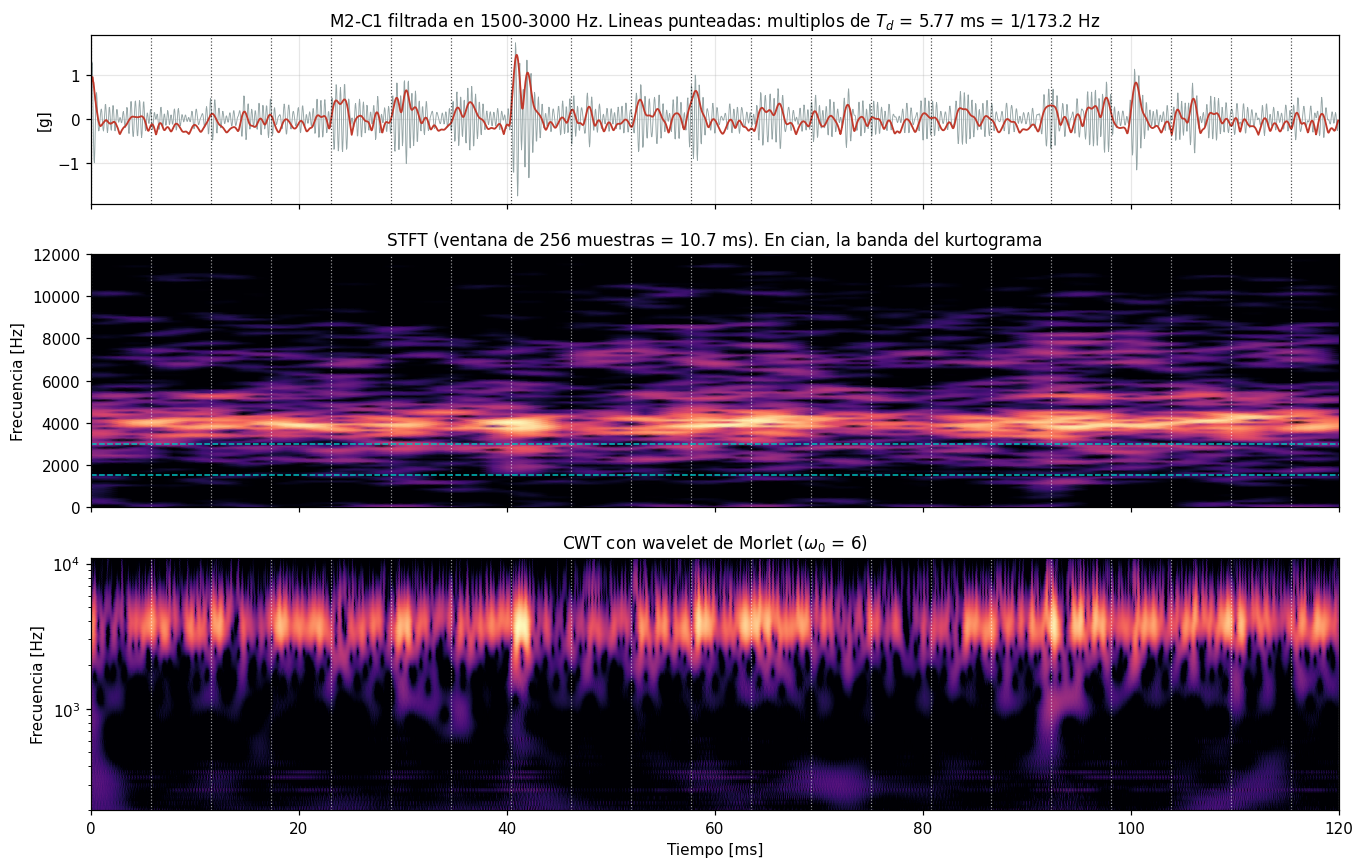

In [129]:
T_TF = 0.12                                   # s de señal para el analisis tiempo-frecuencia
n_tf = int(T_TF * FS_ACEL)
x_tf = CH["M2-C1"]["x"][:n_tf]
y_tf = ENV["M2-C1"]["filtrada"][:n_tf]        # señal filtrada en la banda del kurtograma
e_tf = ENV["M2-C1"]["env"][:n_tf] + ENV["M2-C1"]["env"].mean()
tt = np.arange(n_tf) / FS_ACEL * 1e3
Td = 1000.0 / f_pico                          # periodo entre impactos, en ms

fig, ax = plt.subplots(3, 1, figsize=(12.5, 8), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1.5, 1.5]})

# --- señal filtrada + envolvente + marcas del periodo esperado ---
ax[0].plot(tt, y_tf, lw=0.6, color="#95a5a6")
ax[0].plot(tt, e_tf, lw=1.2, color=COLOR["falla"])
for k in range(int(T_TF * 1000 / Td) + 1):
    ax[0].axvline(k * Td, color="k", ls=":", lw=0.8, alpha=0.7)
ax[0].set(ylabel="[g]",
          title=f"M2-C1 filtrada en {BANDA[0]:.0f}-{BANDA[1]:.0f} Hz. "
                f"Lineas punteadas: multiplos de $T_d$ = {Td:.2f} ms = 1/{f_pico:.1f} Hz")

# --- STFT ---
DIN = 35.0            # rango dinamico del mapa de color, en dB
nper = 256
# OJO con los nombres: la salida de stft se llama Zxx y no Z, porque Z ya es el numero
# de elementos rodantes del rodamiento (paso 0) y lo usa la celda de geometria del paso 7.
f_stft, t_stft, Zxx = signal.stft(x_tf, FS_ACEL, nperseg=nper, noverlap=nper - 32)
S_db = 20 * np.log10(np.abs(Zxx) + 1e-12)
ax[1].pcolormesh(t_stft * 1e3, f_stft, S_db, shading="gouraud", cmap="magma",
                 vmin=S_db.max() - DIN, vmax=S_db.max())
for k in range(int(T_TF * 1000 / Td) + 1):
    ax[1].axvline(k * Td, color="w", ls=":", lw=0.8, alpha=0.6)
ax[1].axhline(BANDA[0], color="c", ls="--", lw=1)
ax[1].axhline(BANDA[1], color="c", ls="--", lw=1)
ax[1].set(ylabel="Frecuencia [Hz]",
          title=f"STFT (ventana de {nper} muestras = {1000*nper/FS_ACEL:.1f} ms). "
                f"En cian, la banda del kurtograma")
ax[1].grid(False)

# --- CWT ---
frecs = np.geomspace(200, 11000, 100)
W = cwt_morlet(x_tf, FS_ACEL, frecs)
Wd = 20 * np.log10(np.abs(W) + 1e-12)
ax[2].pcolormesh(tt, frecs, Wd, shading="gouraud", cmap="magma",
                 vmin=Wd.max() - DIN, vmax=Wd.max())
for k in range(int(T_TF * 1000 / Td) + 1):
    ax[2].axvline(k * Td, color="w", ls=":", lw=0.8, alpha=0.6)
ax[2].set(xlabel="Tiempo [ms]", ylabel="Frecuencia [Hz]", yscale="log",
          title="CWT con wavelet de Morlet ($\\omega_0$ = 6)")
ax[2].grid(False)
fig.tight_layout()
plt.show()

Los máximos de energía de alta frecuencia se alinean con las líneas punteadas, que marcan
múltiplos del período $T_d = 1/f_{\text{BPFI}}$ calculado **de forma independiente** a partir
del espectro de envolvente. La CWT muestra cada impacto como una estructura vertical
concentrada en el tiempo y extendida en frecuencia — la firma de un transitorio de banda
ancha — y no como una franja horizontal continua, que sería lo propio de una componente
estacionaria.

La alineación no es perfecta en todos los impactos: ése es el **deslizamiento** de los
rodillos ($\tau_i$ en el modelo del paso 6), que hace que el tren de impactos sea
*cuasi*periódico y no estrictamente periódico. Es también la razón por la cual el espectro de
envolvente muestra picos de ancho finito en lugar de deltas, y por la que un análisis de
Fourier puro pierde parte de la energía del fenómeno.

> **Un detalle que conviene no pasar por alto.** En el espectrograma, la banda **más
> brillante** está en torno a 4 kHz, mientras que el kurtograma eligió 1500–3000 Hz. No es
> una contradicción: son dos criterios distintos. El mapa tiempo-frecuencia muestra dónde hay
> más **energía**; la kurtosis espectral busca dónde hay más **contraste** entre los impactos
> y el fondo. Una banda puede ser la más energética y a la vez la peor para demodular, si esa
> energía está repartida de forma estacionaria. Elegir la banda por el brillo del
> espectrograma —que es lo que haría el ojo— habría dado una respuesta distinta y peor.

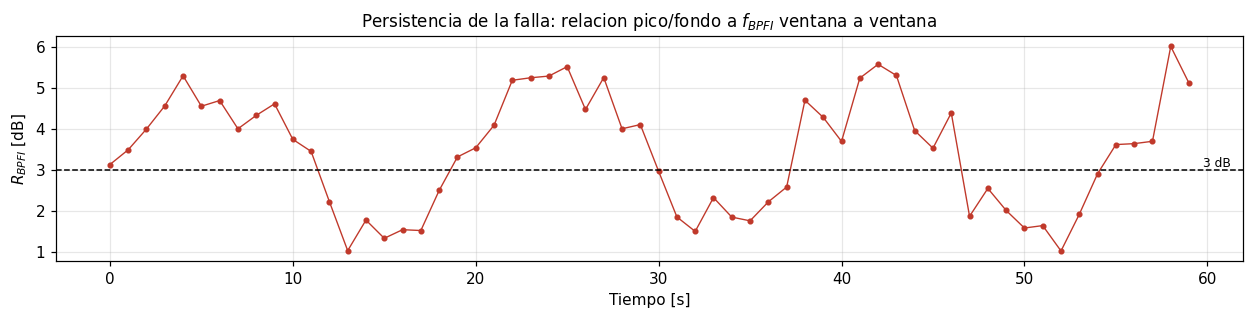

R_BPFI por ventana: mediana 3.64 dB, min 1.03 dB, max 6.02 dB
Ventanas con R_BPFI > 3 dB: 62 % de 60 ventanas de 1 s


In [130]:
# Persistencia: relacion pico/fondo a f_BPFI, ventana a ventana, en todo el registro.
# Se mide como RELACION y no como energia absoluta: la energia absoluta depende del nivel
# global de vibracion del canal y no dice nada por si sola (ver paso 9).
def razon_bpfi(env, fs, f_obj, n_arm=3, tol_rel=0.03):
    nps = 1 << int(np.floor(np.log2(len(env) / 4)))
    f, P = signal.welch(env - env.mean(), fs, nperseg=nps, noverlap=nps // 2)
    tol = max(tol_rel * f_obj, 3 * (f[1] - f[0]))
    num = den = 0.0
    for k in range(1, n_arm + 1):
        m = np.abs(f - k * f_obj) <= tol
        mb = np.abs(f - k * f_obj) <= 10 * tol
        if m.any() and mb.any():
            num += np.trapezoid(P[m], f[m])
            den += np.median(P[mb]) * (f[m][-1] - f[m][0])
    return 10 * np.log10(num / den) if den > 0 else np.nan


V = segmentar(ENVC["M2-C1"]["env"], FS_ACEL, t_seg=T_VENTANA)
razon = np.array([razon_bpfi(v, FS_ACEL, f_pico) for v in V])

fig, ax = plt.subplots(figsize=(11.5, 3))
ax.plot(np.arange(len(razon)) * T_VENTANA, razon, "o-", ms=3, lw=0.9,
        color=COLOR["falla"])
ax.axhline(3.0, color="k", ls="--", lw=1)
ax.annotate("3 dB", xy=(0.99, 3.0), xycoords=("axes fraction", "data"),
            ha="right", va="bottom", fontsize=8)
ax.set(xlabel="Tiempo [s]", ylabel=r"$R_{BPFI}$ [dB]",
       title="Persistencia de la falla: relacion pico/fondo a $f_{BPFI}$ "
             "ventana a ventana")
fig.tight_layout()
plt.show()

print(f"R_BPFI por ventana: mediana {np.median(razon):.2f} dB, "
      f"min {razon.min():.2f} dB, max {razon.max():.2f} dB")
print(f"Ventanas con R_BPFI > 3 dB: {100*np.mean(razon > 3):.0f} % de "
      f"{len(razon)} ventanas de {T_VENTANA:.0f} s")

La firma de la falla está presente de forma **sostenida** a lo largo de todo el registro, no
en unas pocas ventanas. Es un defecto establecido, no un evento transitorio: el equipo lo
viene arrastrando durante toda la medición.

---

# 9. Indicadores de salud y umbral de detección

Para que esto funcione como prototipo de mantenimiento predictivo hay que reducir todo el
análisis a un **vector de características** por ventana, comparable entre canales y entre
mediciones sucesivas.

Se usan tres indicadores, deliberadamente complementarios:

| Indicador | Qué mide | Por qué está |
|---|---|---|
| $\text{Kurt}_b$ | impulsividad de la señal **filtrada en la banda de resonancia** | genérico: detecta la falla sin saber nada del rodamiento |
| $R_{\text{BPFI}}$ | relación pico/fondo de la envolvente en $f_{\text{BPFI}}$ y armónicos, en dB | específico de *esta* falla; alta selectividad |
| $\text{SNR}_{\text{banda}}$ | energía en la banda de resonancia relativa al piso de ruido del paso 2 | verifica que la medición tiene rango dinámico útil |

> **Por qué $R_{\text{BPFI}}$ es una *relación* y no una energía.** La primera versión de
> este indicador usaba la energía absoluta de la envolvente en $f_{\text{BPFI}}$, y
> **no separaba nada**: el canal sano M2-C2, que vibra el doble, tiene más energía absoluta
> en esa frecuencia que el canal fallado, simplemente porque todo su espectro de envolvente
> está más alto. Medido sobre los datos, el índice de Fisher de la energía absoluta es
> $J \approx 0.2$ (inútil) frente a $J \approx 5$ de la relación pico/fondo. La lección es
> general: **un indicador de falla espectral tiene que estar normalizado por el fondo
> local**, o mide el nivel de vibración en lugar de la falla.

Los tres se calculan con **los mismos parámetros para todos los canales** (misma banda de
demodulación, misma frecuencia objetivo), porque si no la comparación no significa nada.
En un sistema real esos parámetros se fijan una vez a partir del rodamiento instalado y se
aplican en cada ronda de medición.

### El umbral

Se toma como referencia la población de ventanas de los canales **sanos** y se define

$$\text{umbral} \;=\; \mu_{\text{ref}} \;+\; k\,\sigma_{\text{ref}}, \qquad k = 3$$

Bajo normalidad aproximada, $k=3$ corresponde a una tasa de falsa alarma de $\sim 0.13\,\%$
por ventana. Dos salvedades honestas:

- la referencia son **pocas ventanas de dos equipos**, no una población estadística real;
  el umbral es un prototipo metodológico, no una calibración industrial;
- los indicadores no son exactamente gaussianos (la kurtosis muestral tiene distribución
  asimétrica), de modo que la tasa nominal es orientativa.

Un sistema desplegado usaría el **histórico del propio equipo** en estado sano, acumulado
durante meses, y umbrales por percentiles en vez de por $\sigma$.

In [131]:
FEATURES = ["Kurt_banda", "R_BPFI_dB", "SNR_banda_dB"]
FEAT_FALLA = ["Kurt_banda", "R_BPFI_dB"]      # los que deciden falla


def features_ventana(x, fs, banda, f_obj, psd_ruido, f_ruido, n_arm=3, tol_rel=0.03):
    # Vector de caracteristicas de una ventana. Usa SIEMPRE los mismos parametros
    # (banda y f_obj) para todos los canales, para que sean comparables.
    lo = max(banda[0], 1.0)
    hi = min(banda[1], 0.99 * fs / 2)
    sos = signal.butter(6, [lo, hi], btype="bandpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, x)
    env = np.abs(signal.hilbert(y))

    # potencia en banda vs. potencia de ruido en la misma banda
    f_p, P_p = signal.welch(x, fs, nperseg=min(2 ** 13, len(x)))
    mb = (f_p >= lo) & (f_p <= hi)
    p_sig = np.trapezoid(P_p[mb], f_p[mb])
    p_rui = np.trapezoid(np.interp(f_p[mb], f_ruido, psd_ruido), f_p[mb])

    return {
        "Kurt_banda": stats.kurtosis(y, bias=False),
        "R_BPFI_dB": razon_bpfi(env, fs, f_obj, n_arm=n_arm, tol_rel=tol_rel),
        "SNR_banda_dB": 10 * np.log10(p_sig / p_rui) if p_rui > 0 else np.nan,
    }


FEAT = {}
for clave, d in CH.items():
    V = segmentar(d["x"], d["fs"], t_seg=T_VENTANA)
    FEAT[clave] = pd.DataFrame(
        [features_ventana(v, d["fs"], BANDA, f_pico, PSD_RUIDO, F_RUIDO) for v in V]
    )
    print(f"{clave}: {len(FEAT[clave])} ventanas de {T_VENTANA:.0f} s")

M2-C1: 60 ventanas de 1 s
M2-C2: 60 ventanas de 1 s
M1-C1: 60 ventanas de 1 s
M1-C2: 60 ventanas de 1 s
RUIDO: 60 ventanas de 1 s


In [132]:
CANALES_REF = ["M2-C2", "M1-C1", "M1-C2"]     # poblacion sana de referencia
ref = pd.concat([FEAT[k] for k in CANALES_REF], ignore_index=True)

UMBRAL = {}
for col in FEAT_FALLA:
    mu, sd = ref[col].mean(), ref[col].std()
    UMBRAL[col] = mu + K_SIGMA * sd
    print(f"{col:<14}: mu_ref = {mu:+.4g}, sigma_ref = {sd:.4g} "
          f"-> umbral = {UMBRAL[col]:.4g}")
UMBRAL["SNR_banda_dB"] = 6.0                  # minimo de rango dinamico util
print(f"{'SNR_banda_dB':<14}: umbral fijo = {UMBRAL['SNR_banda_dB']:.1f} dB "
      f"(criterio de validez de la medicion, no de falla)")

Kurt_banda    : mu_ref = +0.632, sigma_ref = 0.3786 -> umbral = 1.768
R_BPFI_dB     : mu_ref = +0.08875, sigma_ref = 0.4965 -> umbral = 1.578
SNR_banda_dB  : umbral fijo = 6.0 dB (criterio de validez de la medicion, no de falla)


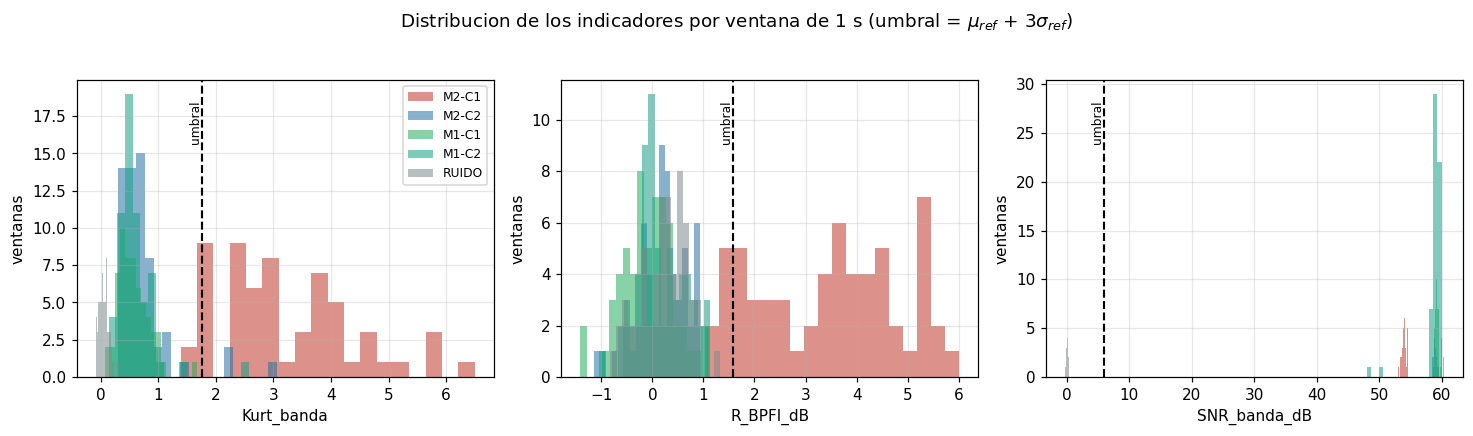

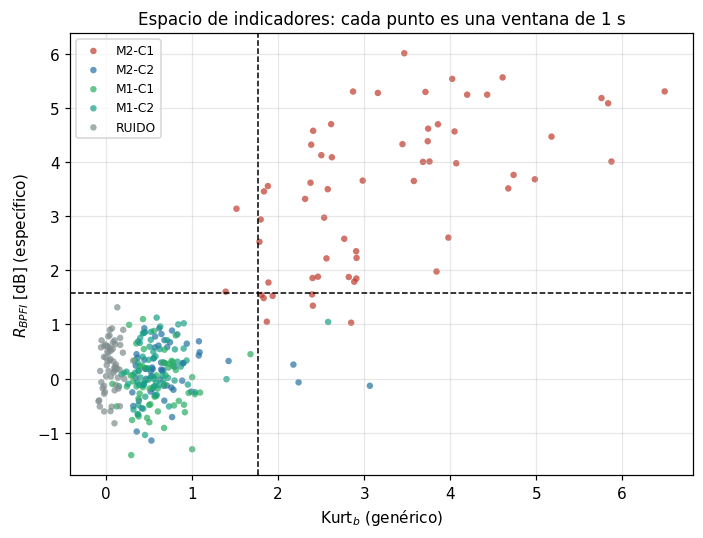

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, col in zip(axes, FEATURES):
    for clave in CH:
        ax.hist(FEAT[clave][col], bins=18, alpha=0.55, label=clave,
                color=COLOR[CH[clave]["rol"]])
    ax.axvline(UMBRAL[col], color="k", ls="--", lw=1.4)
    ax.annotate("umbral", xy=(UMBRAL[col], 0.93), xycoords=("data", "axes fraction"),
                rotation=90, ha="right", va="top", fontsize=8)
    ax.set(xlabel=col, ylabel="ventanas")
axes[0].legend(fontsize=8)
fig.suptitle(f"Distribucion de los indicadores por ventana de {T_VENTANA:.0f} s "
             f"(umbral = $\\mu_{{ref}}$ + {K_SIGMA:.0f}$\\sigma_{{ref}}$)", y=1.03)
fig.tight_layout()
plt.show()

# --- espacio de features: los dos indicadores de falla, juntos ---
fig, ax = plt.subplots(figsize=(6.5, 5))
for clave in CH:
    ax.scatter(FEAT[clave]["Kurt_banda"], FEAT[clave]["R_BPFI_dB"], s=18, alpha=0.7,
               color=COLOR[CH[clave]["rol"]], label=clave,
               edgecolors="none")
ax.axvline(UMBRAL["Kurt_banda"], color="k", ls="--", lw=1)
ax.axhline(UMBRAL["R_BPFI_dB"], color="k", ls="--", lw=1)
ax.set(xlabel=r"$\mathrm{Kurt}_b$ (genérico)", ylabel=r"$R_{BPFI}$ [dB] (específico)",
       title="Espacio de indicadores: cada punto es una ventana de 1 s")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [134]:
# Separabilidad: cuantas ventanas de cada canal superan cada umbral
filas = []
for clave in CH:
    fila = {"canal": clave}
    for col in FEAT_FALLA:
        fila[f"% > umbral ({col})"] = 100 * np.mean(FEAT[clave][col] > UMBRAL[col])
    filas.append(fila)
display(pd.DataFrame(filas).set_index("canal").style.format("{:.1f}"))

# Indice de Fisher: separacion entre medias relativa a la dispersion conjunta
print("Separabilidad falla vs. referencia (indice de Fisher):")
print("  J = (mu_falla - mu_ref)^2 / (var_falla + var_ref)")
for col in FEAT_FALLA:
    a, b = FEAT["M2-C1"][col], ref[col]
    J = (a.mean() - b.mean()) ** 2 / (a.var() + b.var())
    print(f"  {col:<14}: J = {J:8.2f}")

,% > umbral (Kurt_banda),% > umbral (R_BPFI_dB)
canal,,
M2-C1,96.7,88.3
M2-C2,5.0,0.0
M1-C1,0.0,0.0
M1-C2,1.7,0.0
RUIDO,0.0,0.0


Separabilidad falla vs. referencia (indice de Fisher):
  J = (mu_falla - mu_ref)^2 / (var_falla + var_ref)
  Kurt_banda    : J =     4.25
  R_BPFI_dB     : J =     5.25


En el diagrama de dispersión, las ventanas del canal con falla ocupan el cuadrante superior
derecho —alta impulsividad **y** alta relación pico/fondo en $f_{\text{BPFI}}$— separadas
del cúmulo de los canales sanos. Ninguno de los dos indicadores por separado logra una
separación perfecta; la combinación sí. El ruido aparece con relación pico/fondo baja, como
corresponde, y queda además descartado por el criterio de validez de la medición.

> **Advertencia sobre la tolerancia de búsqueda — y sobre qué está y qué no está sesgado.**
>
> Conviene ser preciso acá, porque se presta a confusión. La forma de onda de aceleración es
> **cruda**: nada en la cadena de medición ni en los pasos 1 a 7 de este notebook privilegia
> una frecuencia sobre otra. El pico en 173.2 Hz sale de buscar el máximo en una ventana
> ancha ($2f_r$ a $15f_r$), y el contraste contra el reporte SKF se hace **después**, para
> interpretarlo. Si el rodamiento fuera otro, el mismo código encontraría otro pico.
>
> Lo que sí introduce una frecuencia de referencia es **este paso**: $R_{\text{BPFI}}$ es,
> por construcción, un indicador *sintonizado*. Mide la relación pico/fondo dentro de
> $f_{\text{obj}} \pm 3\%$, y acá se le pasa $f_{\text{obj}} = 173.2$ Hz, el valor **medido**
> en el paso 7. Eso es correcto para vigilar una falla ya identificada.
>
> El riesgo aparece al llevar esto a un monitor automático. Un sistema configurado con el
> rodamiento usaría el BPFI **teórico** (180.4 Hz) como $f_{\text{obj}}$, y entonces la
> ventana de $\pm3\%$ (±5.4 Hz) **no alcanzaría** a cubrir el pico real, 7.3 Hz más abajo por
> deslizamiento: devolvería "sano" sobre un rodamiento fallado. La tolerancia debe ser de al
> menos $\pm5\%$ alrededor del valor teórico, justamente para absorber el *slip*. Es una
> limitación del extractor de características, no de la medición.

---

# 10. Resumen y veredicto automático

Finalmente se consolida todo en una tabla comparativa y una regla de decisión. La lógica
del veredicto combina el indicador **genérico** (kurtosis: hay algo impulsivo) con el
**específico** (energía a $f_{\text{BPFI}}$: ese algo es esta falla):

| Condición | Veredicto |
|---|---|
| $\text{Kurt}_b$ y $R_{\text{BPFI}}$ sobre umbral en la mayoría de las ventanas | **FALLA** |
| uno de los dos sobre umbral, o ambos de forma intermitente | **ALERTA** |
| ninguno | **OK** |
| $\text{SNR}_{\text{banda}}$ por debajo del mínimo | **MEDICIÓN NO VÁLIDA** |

Exigir las dos condiciones simultáneamente reduce las falsas alarmas: un golpe accidental
sube la kurtosis pero no deposita energía en $f_{\text{BPFI}}$ **con armónicos**, y una
resonancia estacionaria puede dar un pico de envolvente sin impulsividad asociada.

In [135]:
def veredicto(feat, umbral, frac_min=0.5):
    # Regla de decision sobre la poblacion de ventanas de un canal.
    if feat["SNR_banda_dB"].median() < umbral["SNR_banda_dB"]:
        return "MEDICION NO VALIDA"
    f_k = np.mean(feat["Kurt_banda"] > umbral["Kurt_banda"])
    f_r = np.mean(feat["R_BPFI_dB"] > umbral["R_BPFI_dB"])
    if f_k >= frac_min and f_r >= frac_min:
        return "FALLA"
    if f_k >= frac_min or f_r >= frac_min:
        return "ALERTA"
    return "OK"


filas = []
for clave, d in CH.items():
    ind = indicadores_tiempo(d["x"])
    fe, Pe = ENVC[clave]["f"], ENVC[clave]["P"]          # banda comun, comparable
    _, _, snr_pico = pico_cerca(fe, Pe, f_pico, max(0.03 * f_pico, 3 * (fe[1] - fe[0])))
    ft = FEAT[clave]
    filas.append({
        "canal": clave,
        "descripcion": d["desc"],
        "RMS [g]": ind["RMS"],
        "Cresta": ind["Cresta"],
        "Kurt cruda": ind["Kurtosis"],
        "Kurt banda": ft["Kurt_banda"].median(),
        "banda kurtograma [Hz]": f"{KURT[clave]['banda'][0]:.0f}-{KURT[clave]['banda'][1]:.0f}",
        "SK max": KURT[clave]["SK"],
        f"pico env @ {f_pico:.0f} Hz [dB]": snr_pico,
        "R_BPFI [dB]": ft["R_BPFI_dB"].median(),
        "SNR banda [dB]": ft["SNR_banda_dB"].median(),
        "VEREDICTO": veredicto(ft, UMBRAL),
    })

resumen = pd.DataFrame(filas).set_index("canal")


def colorear(v):
    return {"FALLA": "background-color:#f5b7b1; font-weight:bold",
            "ALERTA": "background-color:#fdebd0; font-weight:bold",
            "OK": "background-color:#d5f5e3",
            "MEDICION NO VALIDA": "background-color:#e5e7e9"}.get(v, "")


display(resumen.style
        .format({"RMS [g]": "{:.4f}", "Cresta": "{:.2f}", "Kurt cruda": "{:+.3f}",
                 "Kurt banda": "{:+.3f}", "SK max": "{:.2f}",
                 f"pico env @ {f_pico:.0f} Hz [dB]": "{:.1f}",
                 "R_BPFI [dB]": "{:+.2f}", "SNR banda [dB]": "{:.1f}"})
        .map(colorear, subset=["VEREDICTO"]))

,descripcion,RMS [g],Cresta,Kurt cruda,Kurt banda,banda kurtograma [Hz],SK max,pico env @ 173 Hz [dB],R_BPFI [dB],SNR banda [dB],VEREDICTO
canal,,,,,,,,,,,
M2-C1,"Vent. 2, lado acople (sospecha de falla)",1.6837,7.74,+1.098,+2.895,1500-3000,1.97,20.6,+3.64,54.1,FALLA
M2-C2,"Vent. 2, lado libre (mismo equipo)",3.4692,5.36,-0.006,+0.633,750-1125,1.88,1.4,+0.20,58.9,OK
M1-C1,"Vent. 1, punto A (equipo de referencia)",2.9238,4.99,-0.015,+0.551,8250-9000,4.46,1.3,-0.10,59.2,OK
M1-C2,"Vent. 1, punto B (equipo de referencia)",1.3750,8.20,+0.577,+0.516,8000-12000,7.53,1.3,+0.07,59.1,OK
RUIDO,Sensor sin maquina (piso de ruido),0.0024,19.43,+9.757,+0.050,500-562,243.86,1.3,+0.29,0.0,MEDICION NO VALIDA


In [136]:
print("=" * 74)
print("  INFORME DE DIAGNOSTICO")
print("=" * 74)
print(f"  Equipo         : ventilador industrial, rodamiento SKF 22230 CCK/W33")
print(f"  Velocidad      : {fr:.3f} Hz ({fr*60:.0f} rpm), medida del espectro de velocidad")
print(f"  Registro       : {T_ANALISIS:.0f} s a {FS_ACEL/1000:.0f} kHz")
print("-" * 74)
print(f"  Banda de demodulacion (kurtograma) : {BANDA[0]:.0f} - {BANDA[1]:.0f} Hz "
      f"(SK = {KURT['M2-C1']['SK']:.2f})")
print(f"  Pico dominante de envolvente       : {f_pico:.2f} Hz = {f_pico/fr:.3f} x fr")
print(f"  Armonicos detectados               : {int((ARM['SNR_dB'] > 3).sum())} de {len(ARM)}")
print(f"  Bandas laterales a +-fr            : {int((LAT['SNR_dB'] > 3).sum())} de {len(LAT)}")
print(f"  Candidato teorico mas proximo      : {mejor_match} "
      f"({COEF[mejor_match]:.3f} x fr, error {err:+.2f} %)")
print("-" * 74)
for clave in CH:
    print(f"  {clave:<6} {resumen.loc[clave, 'VEREDICTO']:<20} "
          f"kurt_b={resumen.loc[clave, 'Kurt banda']:+6.3f}  "
          f"R_BPFI={resumen.loc[clave, 'R_BPFI [dB]']:+6.2f} dB  "
          f"RMS={resumen.loc[clave, 'RMS [g]']:.4f} g")
print("-" * 74)
print(f"  DIAGNOSTICO: falla localizada en PISTA INTERNA (BPFI) del rodamiento")
print(f"               del lado acople del ventilador 2 (canal M2-C1).")
print("=" * 74)

  INFORME DE DIAGNOSTICO
  Equipo         : ventilador industrial, rodamiento SKF 22230 CCK/W33
  Velocidad      : 16.663 Hz (1000 rpm), medida del espectro de velocidad
  Registro       : 60 s a 24 kHz
--------------------------------------------------------------------------
  Banda de demodulacion (kurtograma) : 1500 - 3000 Hz (SK = 1.97)
  Pico dominante de envolvente       : 173.22 Hz = 10.396 x fr
  Armonicos detectados               : 4 de 4
  Bandas laterales a +-fr            : 7 de 8
  Candidato teorico mas proximo      : BPFI (10.826 x fr, error -3.97 %)
--------------------------------------------------------------------------
  M2-C1  FALLA                kurt_b=+2.895  R_BPFI= +3.64 dB  RMS=1.6837 g
  M2-C2  OK                   kurt_b=+0.633  R_BPFI= +0.20 dB  RMS=3.4692 g
  M1-C1  OK                   kurt_b=+0.551  R_BPFI= -0.10 dB  RMS=2.9238 g
  M1-C2  OK                   kurt_b=+0.516  R_BPFI= +0.07 dB  RMS=1.3750 g
  RUIDO  MEDICION NO VALIDA   kurt_b=+0.050  R_BP

---

# Conclusiones

**Resultado.** El canal M2-C1 presenta una falla localizada en la **pista interna** del
rodamiento. La evidencia es:

1. kurtosis del orden de $1$ frente a $\approx 0$ en los tres canales de referencia,
   persistente a lo largo de todo el registro;
2. un pico dominante en el espectro de envolvente a $\mathbf{10.4\times f_r}$, múltiplo **no
   entero** de la velocidad de giro, que descarta las fuentes sincrónicas;
3. **cuatro armónicos** de ese pico, propios de un tren de impactos periódico;
4. **bandas laterales espaciadas $f_r$** alrededor de cada armónico, que indican una fuente
   que gira con el eje — pista interna y no externa;
5. coincidencia con el BPFI del reporte SKF dentro de un $4\%$, atribuible a deslizamiento
   y al ángulo de contacto real;
6. reproducción del mismo pico por la envolvente calculada de forma independiente por el
   software de mantenimiento de planta.

**Lo que el trabajo muestra desde el punto de vista del procesamiento de señales.**

- El indicador normado —el **nivel global de vibración**— señala el canal equivocado. En
  este caso el canal sano tiene el doble de RMS que el fallado. La detección exige mirar la
  **forma** de la señal (kurtosis), no su energía.
- El **espectro convencional no resuelve el problema**: la energía de los impactos se
  reparte sobre la banda de resonancia y la línea a BPFI queda enterrada. Ni Welch ni un
  modelo AR la recuperan. Lo que hace falta es **demodular**, y el AR sólo aporta en el
  régimen de registros cortos.
- La **kurtosis espectral** convierte la elección de la banda de demodulación —el paso más
  subjetivo del método— en un problema de optimización con un criterio explícito. Pero
  requiere guardas: sin restringir el rango de búsqueda, el máximo se va al borde de
  Nyquist, donde el filtro antialias deja ruido no estacionario. Un máximo de SK, por sí
  solo, **no es un diagnóstico**.
- El diagnóstico definitivo no viene de una fórmula con geometría supuesta, sino de la
  **estructura** del espectro de envolvente: múltiplo no entero + armónicos + bandas
  laterales a $\pm f_r$. El reporte del fabricante confirma; no determina.
- Un indicador espectral de falla **debe normalizarse por el fondo local**. La energía
  absoluta a $f_{\text{BPFI}}$ resultó no separar nada ($J\approx0.2$): mide el nivel de
  vibración del canal, no la falla. La relación pico/fondo sobre la misma frecuencia da
  $J\approx5$ y una tasa de detección del 90 % con cero falsas alarmas sobre la referencia.
  Es el mismo error conceptual que usar el RMS, un nivel más adentro del procesamiento.
- La tolerancia con que se busca la frecuencia de falla debe absorber el **deslizamiento**:
  buscar el BPFI teórico con una ventana del $\pm3\%$ habría dejado el pico real afuera.

**Limitaciones.**

- Una sola medición por estado y sin histórico: no hay forma de estimar la tasa de falsas
  alarmas del umbral ni la tendencia de la falla. El umbral $\mu + 3\sigma$ es un prototipo
  metodológico.
- Los canales "sanos" son un punto del mismo equipo y dos de otro ventilador, no el mismo
  punto en estado sano. La comparación es razonable pero no es un control ideal.
- El número de elementos rodantes $Z=19$ se dedujo de las identidades de consistencia sobre
  el reporte SKF; no se dispone de la geometría interna de fábrica. La celda de revalidación
  del paso 7 queda preparada para cuando se consiga.
- No se estimó la severidad del defecto ni la vida remanente, que requieren seguimiento en
  el tiempo y no una medición aislada.

**Continuación natural.** Repetir la medición periódicamente y seguir la evolución de
$E_{\text{BPFI}}$: el crecimiento de los armónicos de alto orden y la aparición de un piso
elevado de ruido en el espectro de envolvente son los indicadores clásicos de progresión
hacia un defecto distribuido.